# Imports

In [ ]:
from __future__ import annotations

# stdlib
import math
import os
import random
import sys
from abc import ABC, abstractmethod
from concurrent.futures import ProcessPoolExecutor, as_completed
from dataclasses import dataclass
from functools import partial
from multiprocessing import Pool
from typing import Any, Callable, List, Optional

# third-party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy import stats
from scipy.optimize import minimize
from tqdm.notebook import tqdm

def mute_prints():
    sys._stdout = sys.stdout
    sys.stdout = open(os.devnull, 'w')

def unmute_prints():
    sys.stdout.close()
    sys.stdout = sys._stdout

# Classes

## Board

In [ ]:
class Board:
    def __init__(self):
        self.safeSquares = [-1, 0, 13, 26, 39, 53, 54, 55, 56, 57, 58]
        self.boardEnd = 52

    def get_wrap_range(self, start: int, end: int) -> list[int]:
        """
        Return inclusive wraparound sequence from `start` to `end` on a circular board.
        """
        start = start % self.boardEnd
        end = end % self.boardEnd

        result = []
        pos = start
        for _ in range(self.boardEnd + 1):
            result.append(pos)
            if pos == end:
                return result
            pos = (pos + 1) % self.boardEnd

        raise RuntimeError(f"wrap_range failed to reach end={end} from start={start}")

    def get_occupants(self, position: int, players: list, exclude_player_name: str = None) -> list:
        """
        Returns a list of pieces currently at the specified position,
        ignoring pieces belonging to `exclude_player_name`.
        """
        occupying_pieces = []
        for player in players:
            if player.name == exclude_player_name:
                continue
            for piece in player.pieces:
                if piece.position == position:
                    occupying_pieces.append(piece)
        return occupying_pieces

class Dice:
    def roll(self):
        value = random.randint(1, 6)
        return value

## Game

In [ ]:
class Game:
    def __init__(self, players: list, board: Board, dice: Dice):
        self.players = players
        self.board = board
        self.dice = dice
        self.current_turn_index = random.randint(0, len(players) - 1)
        self.winner = None
        self.roll = 0
        self.log = ["Game started!"]
        self.legal_move_count = []

        names = [p.name for p in players]
        if len(set(names)) != len(names):
            raise ValueError(f"Duplicate player names: {names}")

    def clone(self):
        new_game = Game.__new__(Game)   # skip __init__
        new_game.players = [p.clone() for p in self.players]
        new_game.board = self.board          # if board itself never mutates, share it
        new_game.current_turn_index = self.current_turn_index
        new_game.winner = self.winner
        new_game.dice = self.dice
        new_game.roll = self.roll
        for p in new_game.players:            # fix up owner back-references
          for piece in p.pieces:
            piece.owner = p
        return new_game

    def start_game(self):
        while not self.winner:
            self.play_turn()
            self.check_winner()
        self.log.append(f"Winner is {self.winner.name}!")

    def apply_move(self, player_index, move):
      """
      Applies move using piece.new_position
      """
      player = self.players[player_index]
      piece_id, action, roll = move
      captured = []

      if piece_id is None:
          return captured

      piece = next(p for p in player.pieces if p.id == piece_id)

      if action == "activate":
          piece.activate(player)

      elif action == "move":
          new_pos = piece.new_position(roll, player, self.board)
          piece.position = new_pos

          if new_pos not in self.board.safeSquares:
              occupants = self.board.get_occupants(
                  new_pos, self.players, exclude_player_name=player.name
              )
              for opp_piece in occupants:
                  opp_piece.killed()
                  opp_piece.owner.got_captured_count += 1
                  player.capture_count += 1
                  captured.append(opp_piece)

      return captured


    def play_turn(self):"
        current_player = self.players[self.current_turn_index]
        self.log.append(f"{current_player.name}'s turn.")

        self.roll = self.dice.roll()

        current_player.roll_count += 1
        self.log.append(f"{current_player.name} rolled a {self.roll}")
        valid_moves = self.get_valid_moves(current_player, self.roll)
        valid_moves_count = len(valid_moves)
        self.legal_move_count.append(valid_moves_count)
        # The player decides what they want to do
        piece, action = current_player.make_decision(self.roll, self.board, self.players)

        # The Game executes the action
        if piece is None:
            self.log.append(f"{current_player.name} didn't move")
        else:
            move = (piece.id, action, self.roll)
            captured = self.apply_move(self.current_turn_index, move)

            if action == "activate":
                self.log.append(f"{current_player.name} activated piece {piece.id}")
            elif action == "move":
                self.log.append((f"{current_player.name} moved piece "
                            f"{piece.id} {self.roll} steps"))
            for opp_piece in captured:
                self.log.append(f"Piece {opp_piece.id} was captured!")

        self.log.append(f"{current_player.name}'s positions:")
        for p in current_player.pieces:
            self.log.append(f"Piece {p.id} is at position {p.position}")

        self.next_turn()




    def seat_after(self, player_index):
        return (player_index + 1) % len(self.players)

    def next_turn(self): #bonus turn handling
        if self.roll != 6:
            self.current_turn_index = self.seat_after(self.current_turn_index)

    def get_valid_moves(self, player, roll):
        valid_moves = []
        for piece in player.pieces:
            if piece.check_move_valid(roll) or piece.can_activate(roll):
                valid_moves.append(piece)
        return valid_moves



    def check_winner(self):
        current_player = self.players[self.current_turn_index]
        if current_player.has_won():
            self.winner = current_player
            return True
        return False

## Piece

In [ ]:
class Piece:
    def __init__(self, id, owner):
        self.id = id
        self.position: int = -1
        self.isSafe = True
        self.priority = 0
        self.offset = 0
        self.completed = False
        self.owner = owner

    def clone(self):
      new_piece = Piece.__new__(Piece)
      new_piece.id = self.id
      new_piece.position = self.position
      new_piece.isSafe = self.isSafe
      new_piece.priority = self.priority
      new_piece.offset = self.offset
      new_piece.completed = self.completed
      new_piece.owner = None
      return new_piece

    def full_clone(self):
      new_piece = Piece.__new__(Piece)
      new_piece.id = self.id
      new_piece.position = self.position
      new_piece.isSafe = self.isSafe
      new_piece.priority = self.priority
      new_piece.offset = self.offset
      new_piece.completed = self.completed
      new_piece.owner = self.owner
      return new_piece


    def activate(self, player):
        self.position = player.startPoint

    def killed(self):
        self.position = -1

    def check_safe(self, board: Board):
        self.isSafe = self.position in board.safeSquares

    def check_move_valid(self, steps: int) -> bool:
        try:
            pos = int(self.position)
            steps = int(steps)
        except (TypeError, ValueError):
            raise TypeError(f"position and steps must be ints; got position={self.position!r}, steps={steps!r}")

        if pos in (-1, 58):
            return False
        if 0 <= pos <= 52:
            return True
        if 53 <= pos < 58:
            return steps <= (58 - pos)
        return False

    def new_position(self, steps: int, player, board: Board) -> int:
        if self.check_move_valid(steps):
            pos = self.position
            for _ in range(steps):
                if pos >= 53:
                    pos += 1
                else:
                    pos = (pos + 1) % board.boardEnd
                    if pos == player.startPoint:
                        pos = 53
            return pos
        return self.position

    def distance_to_completion(self, player, board: Board) -> int:
        if self.position == -1:
            return 59
        if 0 <= self.position <= board.boardEnd:
            steps_to_spawn = (player.startPoint - self.position - 1) % board.boardEnd
            return steps_to_spawn + 6 + 1
        if 53 <= self.position <= 57:
            return 58 - self.position
        if self.position == 58:
            return 0

    def can_activate(self, steps: int) -> bool:
        return steps == 6 and self.position == -1

    def can_complete(self, steps: int) -> bool:
        return self.position == 58 - steps

    def can_reach_safe_space(self, steps: int, player, board: Board) -> bool:
        if self.check_move_valid(steps):
            return self.new_position(steps, player, board) in board.safeSquares
        return False

    def can_capture(self, steps: int, player, players: list, board: Board) -> bool:
        if self.check_move_valid(steps):
            new_pos = self.new_position(steps, player, board)
            if new_pos not in board.safeSquares:
                occupants = board.get_occupants(new_pos, players, exclude_player_name=player.name)
                return len(occupants) > 0
        return False

    def is_threatened(self, player_name: str, players: list, board: Board) -> bool:
      if self.position in board.safeSquares or self.position < 0:
          return False

      danger_zone = board.get_wrap_range(self.position - 6, self.position - 1)
      for square in danger_zone:
          for piece in board.get_occupants(square, players, exclude_player_name=player_name):
              entry = (piece.owner.startPoint - 1) % board.boardEnd
              if entry not in board.get_wrap_range(square, self.position - 1):
                  return True
      return False

    def can_escape(self, steps: int, player_name: str, players: list, board: Board) -> bool:
      if self.position in board.safeSquares or self.position < 0:
          return False
      if not self.is_threatened(player_name, players, board):
          return False

      temp_piece = self.full_clone()

      if temp_piece.check_move_valid(steps):
        temp_piece.position = self.new_position(steps, self.owner, board)
        return not temp_piece.is_threatened(player_name, players, board)
      else:
        return False

    def is_threatening(self, player_name: str, players: list, board: Board) -> bool:
        threat_zone = board.get_wrap_range(self.position + 1, self.position + 6)
        for square in threat_zone:
          occupants = board.get_occupants(square, players, exclude_player_name=player_name)
          if len(occupants) > 0:
            return True
        return False

    def can_threaten(self, steps: int, player, players: list, board: Board) -> bool:
        if self.check_move_valid(steps) and steps < self.distance_to_completion(player, board):
            new_pos = self.new_position(steps, player, board)
            threat_zone = board.get_wrap_range(new_pos + 1, new_pos + 6)
            for square in threat_zone:
              occupants = board.get_occupants(square, players, exclude_player_name=player.name)
              if len(occupants) > 0:
                return True
        return False


## Decision Systems

###Evaluation Functions and Weight Matrices

In [ ]:
ORIGINAL_W = {
    "finished":   100,
    "progress":     1,
    "active":      10,
    "safe":         6,
    "threatened": -18,
    "capture_bonus": -3
}

FOUR_W = {
    "finished":   37.25,
    "progress":     3.175,
    "active":      30.030,
    "safe":         5.712,
    "threatened": -15.768,
    "tau": 47.494
}

TWO_W = {
    "finished":   37.25,
    "progress":     2.977,
    "active":      27.389,
    "safe":         5.330,
    "threatened": -11.112,
    "capture_bonus": -2.028
}

MAX_DISTANCE = 58

def _player_score(game, player, W):
    board = game.board
    s = 0.0
    for piece in player.pieces:
        if piece.position == 58:
          s += float(W["progress"]) * MAX_DISTANCE + float(W["finished"])
          continue

        if piece.position > -1:
            remaining = piece.distance_to_completion(player, board)
            s += float(W["active"])
            if piece.position in board.safeSquares:
                s += float(W["safe"])
            if piece.is_threatened(player.name, game.players, board):
                s += float(W["threatened"])
        else:
            remaining = MAX_DISTANCE

        s += float(W["progress"]) * (MAX_DISTANCE - remaining)

    return s


def state_evaluator_two(game, player_index, W=None):
    W = W if W is not None else TWO_W
    me = game.players[player_index]
    opponents = [p for i, p in enumerate(game.players) if i != player_index]

    my = _player_score(game, me, W)
    theirs = sum(_player_score(game, o, W) for o in opponents) / len(opponents)

    opp_active = sum( #count opponent active pieces
        sum(1 for pc in o.pieces if -1 < pc.position < 58)
        for o in opponents
    ) / len(opponents)

    return (my - theirs) - float(W["capture_bonus"]) * opp_active #difference in score - capture bonus

def state_evaluator_four(game, player_index, W=None):
    W = W if W is not None else FOUR_W
    tau = float(W.get("tau", 50.0))

    s = np.array([_player_score(game, p, W) for p in game.players]) / tau
    s -= s.max()
    return float(s[player_index] - np.log(np.exp(s).sum()))


### Basic/Enhanced Strategies, Heuristic Strategy, State Evaluation Strategy

In [ ]:
# Abstract class for playing strategies
class DecisionSystem(ABC):
    @abstractmethod
    def make_decision(self, steps: int, board, players: list, current_player):
        pass

class HeuristicStrategy(DecisionSystem):
    def make_decision(self, steps: int, board, players: list, current_player):
        """
        Evaluates pieces, assigns priorities, and returns the chosen piece
        along with the intended action ('activate' or 'move').
        """

        for piece in current_player.pieces:
            if piece.check_move_valid(steps):
                piece.priority = 0 if piece.position in board.safeSquares else 1
            else:
                piece.priority = -1

            if piece.can_complete(steps):
                piece.priority = 2
            if piece.can_threaten(steps, current_player, players, board):
                piece.priority = 3
            if piece.can_reach_safe_space(steps, current_player, board):
                piece.priority = 4
            if piece.can_activate(steps):
                piece.priority = 5
            if piece.can_escape(steps, current_player.name, players, board):
                piece.priority = 6
            if piece.can_capture(steps, current_player, players, board):
                piece.priority = 7

        max_priority = max(p.priority for p in current_player.pieces)

        if max_priority == -1:
            return None, "none" # No valid moves

        best_pieces = [p for p in current_player.pieces if p.priority == max_priority]

        # Selects the piece furthest along, using current_player context for distance calculation
        piece_to_move = min(best_pieces, key=lambda p: p.distance_to_completion(current_player, board))

        action = "activate" if piece_to_move.can_activate(steps) else "move"
        return piece_to_move, action

class RandomStrategy(DecisionSystem):
    def make_decision(self, steps: int, board, players: list, current_player):
        valid_moves = [p for p in current_player.pieces if p.check_move_valid(steps) or p.can_activate(steps)]
        if not valid_moves:
            return None, "none"
        piece_to_move = random.choice(valid_moves)
        action = "activate" if piece_to_move.can_activate(steps) else "move"
        return piece_to_move, action


class FastStrategy(DecisionSystem):
    def make_decision(self, steps: int, board, players: list, current_player):

        valid_pieces = []
        for piece in current_player.pieces:
            if piece.check_move_valid(steps) or piece.can_activate(steps):
                valid_pieces.append(piece)

        if not valid_pieces:
            return None, "none"

        piece_to_move = min(valid_pieces, key=lambda p: p.distance_to_completion(current_player, board))

        if piece_to_move.can_activate(steps):
            return piece_to_move, "activate"

        return piece_to_move, "move"

class EnhancedFastStrategy(DecisionSystem):
    def make_decision(self, steps: int, board, players: list, current_player):

        valid_pieces = []
        for piece in current_player.pieces:
            if piece.check_move_valid(steps) or piece.can_activate(steps):
                valid_pieces.append(piece)

        if not valid_pieces:
            return None, "none"

        for piece in valid_pieces:
            if piece.can_activate(steps):
                return piece, "activate"

        piece_to_move = min(valid_pieces, key=lambda p: p.distance_to_completion(current_player, board))

        return piece_to_move, "move"

class AggressiveStrategy(DecisionSystem):
    def make_decision(self, steps: int, board, players: list, current_player):

        valid_moves = []
        capturing_moves = []

        for piece in current_player.pieces:
            can_move = piece.check_move_valid(steps)
            can_activate = piece.can_activate(steps)

            if not (can_move or can_activate):
                continue

            action = "activate" if can_activate else "move"
            valid_moves.append((piece, action))

            if action == "move" and piece.can_capture(steps, current_player, players, board):
                capturing_moves.append((piece, action))

        if capturing_moves:
            return random.choice(capturing_moves)

        if valid_moves:
          return random.choice(valid_moves)

        return None, "none"

class EnhancedAggressiveStrategy(DecisionSystem):
    def make_decision(self, steps: int, board, players: list, current_player):

        valid_moves = []
        capturing_moves = []

        for piece in current_player.pieces:
            if piece.can_activate(steps):
                return piece, "activate"
            can_move = piece.check_move_valid(steps)
            can_activate = piece.can_activate(steps)

            if not (can_move or can_activate):
                continue

            action = "activate" if can_activate else "move"
            valid_moves.append((piece, action))

            if action == "move" and piece.can_capture(steps, current_player, players, board):
                capturing_moves.append((piece, action))

        if capturing_moves:
            return random.choice(capturing_moves)

        if valid_moves:
          return random.choice(valid_moves)

        return None, "none"

class DefensiveStrategy(DecisionSystem):
    def make_decision(self, steps: int, board, players: list, current_player):

        valid_moves = []
        escaping_moves = []

        for piece in current_player.pieces:
            can_move = piece.check_move_valid(steps)
            can_activate = piece.can_activate(steps)

            if not (can_move or can_activate):
                continue

            action = "activate" if can_activate else "move"
            valid_moves.append((piece, action))

            if action == "move" and piece.can_escape(steps, current_player.name, players, board):
                escaping_moves.append((piece, action))

        if escaping_moves:
            return random.choice(escaping_moves)

        if valid_moves:
            return random.choice(valid_moves)

        return None, "none"

class EnhancedDefensiveStrategy(DecisionSystem):
    def make_decision(self, steps: int, board, players: list, current_player):
        valid_moves = []
        escaping_moves = []

        for piece in current_player.pieces:
            if piece.can_activate(steps):
                return piece, "activate"
            can_move = piece.check_move_valid(steps)
            can_activate = piece.can_activate(steps)

            if not (can_move or can_activate):
                continue

            action = "activate" if can_activate else "move"
            valid_moves.append((piece, action))

            if action == "move" and piece.can_escape(steps, current_player.name, players, board):
                escaping_moves.append((piece, action))

        if escaping_moves:
            return random.choice(escaping_moves)

        if valid_moves:
            for piece, action in valid_moves:
              if piece.can_activate(steps):
                return piece, action
            return random.choice(valid_moves)

        return None, "none"

class MixedStrategy(DecisionSystem):
    def make_decision(self, steps: int, board, players: list, current_player):

        for piece in current_player.pieces:
            if piece.check_move_valid(steps) or piece.can_activate(steps):
                piece.priority = 1
            else:
                piece.priority = -1

            if piece.can_capture(steps, current_player, players, board): # Aggressive
                piece.priority = 2
            if piece.can_escape(steps, current_player, players, board): #Defensive
                piece.priority = 3

        max_priority = max(p.priority for p in current_player.pieces)

        if max_priority == -1:
            return None, "none" # No valid moves

        best_pieces = [p for p in current_player.pieces if p.priority == max_priority]

        # Selects the piece furthest along, using current_player context for distance calculation
        piece_to_move = min(best_pieces, key=lambda p: p.distance_to_completion(current_player, board)) #Fast else Random

        action = "activate" if piece_to_move.can_activate(steps) else "move"
        return piece_to_move, action

class EnhancedMixedStrategy(DecisionSystem):
    def make_decision(self, steps: int, board, players: list, current_player):

        for piece in current_player.pieces:
            if piece.check_move_valid(steps) or piece.can_activate(steps):
                piece.priority = 1
            else:
                piece.priority = -1

            if piece.can_capture(steps, current_player, players, board): # Aggressive
                piece.priority = 2
            if piece.can_escape(steps, current_player, players, board): #Defensive
                piece.priority = 3
            if piece.can_activate(steps): # Prefer Release
                piece.priority = 4

        max_priority = max(p.priority for p in current_player.pieces)

        if max_priority == -1:
            return None, "none" # No valid moves

        best_pieces = [p for p in current_player.pieces if p.priority == max_priority]

        # Selects the piece furthest along, using current_player context for distance calculation
        piece_to_move = min(best_pieces, key=lambda p: p.distance_to_completion(current_player, board)) #Fast else Random

        action = "activate" if piece_to_move.can_activate(steps) else "move"
        return piece_to_move, action

class StateEvalStrategyTwo(DecisionSystem):
    """Evaluate states following available moves on clone games and return the move with the best state"""
    def __init__(self, W=TWO_W):
        self.W = W

    def make_decision(self, steps, board, players, current_player):
        player_index = players.index(current_player)

        temp_game = Game(players, board, Dice())
        temp_game.current_turn_index = player_index

        valid_pieces = temp_game.get_valid_moves(current_player, steps)
        if not valid_pieces:
            return None, "none"

        best_piece, best_action, best_value = None, None, float("-inf")

        for piece in valid_pieces:
            action = "activate" if piece.can_activate(steps) else "move"

            sim_game = temp_game.clone()
            sim_game.current_turn_index = player_index
            sim_game.apply_move(player_index, (piece.id, action, steps))

            value = state_evaluator_two(sim_game, player_index, W=self.W)

            if value > best_value:
                best_piece, best_action, best_value = piece, action, value

        return best_piece, best_action


class StateEvalStrategyFour(DecisionSystem):
    """Evaluate states following available moves on clone games and return the move with the best state"""
    def __init__(self, W=FOUR_W):
        self.W = W

    def make_decision(self, steps, board, players, current_player):
        player_index = players.index(current_player)

        temp_game = Game(players, board, Dice())
        temp_game.current_turn_index = player_index

        valid_pieces = temp_game.get_valid_moves(current_player, steps)
        if not valid_pieces:
            return None, "none"

        best_piece, best_action, best_value = None, None, float("-inf")

        for piece in valid_pieces:
            action = "activate" if piece.can_activate(steps) else "move"

            sim_game = temp_game.clone()
            sim_game.current_turn_index = player_index
            sim_game.apply_move(player_index, (piece.id, action, steps))

            value = state_evaluator_four(sim_game, player_index, W=self.W)

            if value > best_value:
                best_piece, best_action, best_value = piece, action, value

        return best_piece, best_action

## Player

In [ ]:

class Player:
    def __init__(self, name, startPoint, brain: DecisionSystem):
        self.name = name
        self.pieces = [Piece(0, self), Piece(1, self), Piece(2, self), Piece(3, self)]
        self.startPoint = startPoint
        self.brain = brain
        self.roll_count = 0
        self.capture_count = 0
        self.got_captured_count = 0

    def has_won(self) -> bool:
        """Checks if all pieces have reached the end."""
        return all(piece.position == 58 for piece in self.pieces)

    def distance_to_win(self, board: Board) -> int:
        return sum(piece.distance_to_completion(self, board) for piece in self.pieces)


    def make_decision(self, steps: int, board, players: list):
        # The player delegates the thinking entirely to its Decision System
        return self.brain.make_decision(steps, board, players, self)

    def clone(self):
        new_player = Player.__new__(Player)
        new_player.name = self.name
        new_player.pieces = [p.clone() for p in self.pieces]
        new_player.startPoint = self.startPoint
        new_player.brain = self.brain
        new_player.roll_count = self.roll_count
        new_player.capture_count = self.capture_count
        new_player.got_captured_count = self.got_captured_count
        return new_player

## TD(λ)


In [ ]:

def collect_games(n_games, strategy_factories, n_players=2,
                  sample_every=1, drop_last_turns=15,
                  verbose_every=200, seed=None):

    rng = random.Random(seed)
    starts = SEAT_STARTS_2P if n_players == 2 else SEAT_STARTS_4P
    X, y, game_ids = [], [], []

    for g in range(n_games):
        players = [
            Player(f"p{i}", starts[i], rng.choice(strategy_factories)())
            for i in range(n_players)
        ]
        game = Game(players, Board(), Dice())

        snapshots = []
        turn = 0
        while not any(p.has_won() for p in game.players):
            mover = game.current_turn_index
            game.play_turn()
            turn += 1
            if turn % sample_every == 0:
                snapshots.append((turn, mover, encode_state(game, mover)))

        final_turn = turn
        winner = next(i for i, p in enumerate(game.players) if p.has_won())

        for t, pi, x in snapshots:
            if final_turn - t < drop_last_turns:
                continue
            X.append(x)
            y.append(1.0 if pi == winner else 0.0)
            game_ids.append(g)

        if verbose_every and (g + 1) % verbose_every == 0:
            print(f"  {g+1}/{n_games} games, {len(X)} rows", flush=True)

    return (np.array(X, dtype=np.float32),
            np.array(y, dtype=np.float32),
            np.array(game_ids))


def save_dataset(path, X, y, game_ids):
    np.savez_compressed(path, X=X, y=y, game_ids=game_ids)
    print(f"saved {path}: {X.shape[0]} rows, dim {X.shape[1]}")


def load_dataset(path):
    d = np.load(path if path.endswith(".npz") else path + ".npz")
    return d["X"], d["y"], d["game_ids"]


def make_val_mask(game_ids, val_frac=0.15, seed=0):
    games = np.unique(game_ids)
    rng = np.random.RandomState(seed)
    rng.shuffle(games)
    n_val = max(1, int(len(games) * val_frac))
    return np.isin(game_ids, list(set(games[:n_val].tolist())))


def train_supervised(X, y, game_ids, n_players, hidden=(64, 32),
                     epochs=40, batch_size=512, lr=1e-3,
                     val_frac=0.15, patience=6, seed=0, device=None):

    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    torch.manual_seed(seed)

    val_mask = make_val_mask(game_ids, val_frac, seed)
    Xt = torch.from_numpy(X[~val_mask]).to(device)
    yt = torch.from_numpy(y[~val_mask]).to(device)
    Xv = torch.from_numpy(X[val_mask]).to(device)
    yv = torch.from_numpy(y[val_mask]).to(device)
    print(f"train rows {len(Xt)}   val rows {len(Xv)}   "
          f"base rate {y.mean():.3f}", flush=True)

    model = NetEval(n_players, hidden=hidden).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.BCELoss()

    best, best_state, bad = float("inf"), None, 0
    n = len(Xt)

    for ep in range(epochs):
        model.train()
        perm = torch.randperm(n, device=device)
        total = 0.0
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            opt.zero_grad()
            out = model(Xt[idx]).clamp(1e-6, 1 - 1e-6)
            loss = lossf(out, yt[idx])
            loss.backward()
            opt.step()
            total += loss.item() * len(idx)

        model.eval()
        with torch.no_grad():
            pv = model(Xv).clamp(1e-6, 1 - 1e-6)
            vloss = lossf(pv, yv).item()
            vacc = ((pv > 0.5) == (yv > 0.5)).float().mean().item()
        print(f"epoch {ep+1:2d}: train {total/n:.4f}   "
              f"val {vloss:.4f}   acc {vacc:.3f}", flush=True)

        if vloss < best - 1e-4:
            best, bad = vloss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                print(f"early stop after {ep+1} epochs")
                break

    if best_state:
        model.load_state_dict(best_state)
    model.eval()
    return model


def save_model(model, path):
    torch.save({"state_dict": model.state_dict(),
                "n_players": model.n_players}, path)
    print(f"saved {path}")

class NetEvalStrategy:

    def __init__(self, model, name="NetEval", device="cpu", use_logit=False):
        self.model = model.to(device).eval()
        self.device = device
        self.name = name
        self.use_logit = use_logit      # read pre-sigmoid score if values cluster

    def make_decision(self, steps, board, players, current_player_obj):
        pidx = players.index(current_player_obj)
        temp = Game(players, board, Dice())
        temp.current_turn_index = pidx

        valid = temp.get_valid_moves(current_player_obj, steps)
        if not valid:
            return None, "none"

        cands, encs = [], []
        for piece in valid:
            action = "activate" if piece.can_activate(steps) else "move"
            sim = temp.clone()
            sim.current_turn_index = pidx
            sim.apply_move(pidx, (piece.id, action, steps))
            cands.append((piece, action))
            encs.append(encode_state(sim, pidx))

        X = torch.from_numpy(np.stack(encs)).to(self.device)
        with torch.no_grad():
            if self.use_logit:
                h = X
                for layer in list(self.model.net)[:-1]:   # everything but Sigmoid
                    h = layer(h)
                vals = h.squeeze(-1)
            else:
                vals = self.model(X)

        return cands[int(torch.argmax(vals).item())]



In [ ]:

TRACK_LEN = 52
HOME_START = 53
HOME_LEN = 5
FINISH = 58
YARD = -1
MAX_PROGRESS = FINISH

RING_BASE = 0
HOME_BASE = TRACK_LEN                 # 52..56
YARD_SLOT = TRACK_LEN + HOME_LEN      # 57
FIN_SLOT = YARD_SLOT + 1              # 58
SCALAR_BASE = FIN_SLOT + 1            # 59..62
PER_PLAYER = SCALAR_BASE + 4          # 63

SEAT_STARTS_2P = [0, 26]
SEAT_STARTS_4P = [0, 13, 26, 39]

def input_dim(n_players):
    return n_players * PER_PLAYER


def piece_progress(position, start):
    if position == YARD:
        return 0
    if position >= FINISH:
        return MAX_PROGRESS
    if position >= HOME_START:
        return position
    return (position - start) % TRACK_LEN


def encode_state(game, player_index):
    n = len(game.players)
    offset = game.players[player_index].startPoint
    out = np.zeros(input_dim(n), dtype=np.float32)

    for k in range(n):
        pi = (player_index + k) % n
        base = k * PER_PLAYER
        player = game.players[pi]

        for piece in player.pieces:
            p = piece.position
            if p == YARD:
                out[base + YARD_SLOT] += 1.0
            elif p >= FINISH:
                out[base + FIN_SLOT] += 1.0
            elif p >= HOME_START:
                out[base + HOME_BASE + (p - HOME_START)] += 1.0
            elif 0 <= p < TRACK_LEN:
                out[base + RING_BASE + (p - offset) % TRACK_LEN] += 1.0
            else:
                raise ValueError(f"unexpected piece position {p}")

        progs = sorted((piece_progress(pc.position, player.startPoint) / MAX_PROGRESS
                        for pc in player.pieces), reverse=True)
        for j, v in enumerate(progs[:4]):
            out[base + SCALAR_BASE + j] = v

    return out

class NetEval(nn.Module):
    """raw board -> P(win) for the POV player."""

    def __init__(self, n_players, hidden=(64, 32)):
        super().__init__()
        self.n_players = n_players
        d = input_dim(n_players)
        layers = []
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU()]
            d = h
        layers += [nn.Linear(d, 1), nn.Sigmoid()]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

class TDNetStrategy(DecisionSystem):
    """Greedy over afterstates, learning by TD(lambda) with eligibility
    traces. Set .training = False to play without learning or exploring."""

    def __init__(self, model, name="TDNet", alpha=1e-3, lam=0.7,
                 epsilon=0.05, device="cpu"):
        self.model = model.to(device)
        self.device = device
        self.name = name
        self.alpha = alpha
        self.lam = lam
        self.epsilon = epsilon
        self.training = True
        self.traces = [torch.zeros_like(p) for p in self.model.parameters()]
        self._prev_x = None

    def make_decision(self, steps, board, players, current_player_obj):
        pidx = players.index(current_player_obj)

        temp = Game(players, board, Dice())
        temp.current_turn_index = pidx
        valid = temp.get_valid_moves(current_player_obj, steps)
        if not valid:
            return None, "none"

        cands, encs = [], []
        for piece in valid:
            action = "activate" if piece.can_activate(steps) else "move"
            sim = temp.clone()
            sim.current_turn_index = pidx
            sim.apply_move(pidx, (piece.id, action, steps))
            cands.append((piece, action))
            encs.append(encode_state(sim, pidx))

        X = torch.from_numpy(np.stack(encs)).to(self.device)
        with torch.no_grad():
            vals = self.model(X)

        if self.training and random.random() < self.epsilon:
            i = random.randrange(len(cands))
        else:
            i = int(torch.argmax(vals).item())

        if self.training:
            self._observe(X[i])

        return cands[i]

    def _observe(self, x):
        if self._prev_x is not None:
            with torch.no_grad():
                target = float(self.model(x.unsqueeze(0)).item())
            self._td_step(target)
        self._prev_x = x.clone()

    def _td_step(self, target):
        v = self.model(self._prev_x.unsqueeze(0))
        self.model.zero_grad()
        v.backward()
        delta = target - float(v.item())

        with torch.no_grad():
            for p, z in zip(self.model.parameters(), self.traces):
                if p.grad is None:
                    continue
                z.mul_(self.lam).add_(p.grad)
                z.clamp_(-10.0, 10.0)
                p.add_(self.alpha * delta * z)
        self.model.zero_grad()

    def finish_episode(self, won):
        if self._prev_x is not None:
            self._td_step(1.0 if won else 0.0)
        self.reset_episode()

    def reset_episode(self):
        for z in self.traces:
            z.zero_()
        self._prev_x = None

def train_td(model, opponent_factories, n_players=2, episodes=20000,
             alpha=1e-3, lam=0.7, epsilon=0.05, freeze_every=1000,
             eval_every=1000, eval_games=300, device="cpu", seed=0):

    rng = random.Random(seed)
    starts = SEAT_STARTS_2P if n_players == 2 else SEAT_STARTS_4P

    agent = TDNetStrategy(model, alpha=alpha, lam=lam, epsilon=epsilon,
                          device=device)
    frozen = None
    curve, norms = [], []

    for ep in range(episodes):
        if ep % freeze_every == 0:
            frozen = _frozen_copy(agent, n_players, device)

        seats = [agent]
        for _ in range(n_players - 1):
            if frozen is not None and rng.random() < 0.5:
                seats.append(frozen)
            else:
                seats.append(rng.choice(opponent_factories)())

        players = [Player(f"p{i}", starts[i], s) for i, s in enumerate(seats)]
        game = Game(players, Board(), Dice())
        while not any(p.has_won() for p in game.players):
            game.play_turn()

        agent.finish_episode(won=game.players[0].has_won())
        norms.append(float(sum(p.norm().item() for p in model.parameters())))

        if (ep + 1) % eval_every == 0:
            wr = _evaluate_td_net(agent, opponent_factories, n_players,
                          eval_games, starts, rng)
            curve.append((ep + 1, wr))
            print(f"ep {ep+1}: win rate {wr:.3f}   |w| {norms[-1]:.2f}",
                  flush=True)
            if norms[-1] > 20 * norms[0]:
                print("WARNING: weight norm growing fast — lower alpha")

    import torch
    from datetime import datetime

    stamp = datetime.now().strftime("%Y%m%d_%H%M")
    path = f"drive/MyDrive/tdnet_{model.n_players}p_{stamp}.pt"

    torch.save({
        "state_dict": model.state_dict(),
        "n_players": model.n_players,
        "hidden": (64, 32),
        "alpha": agent.alpha,
        "lam": agent.lam,
        "epsilon": agent.epsilon,
        "curve": curve,
        "norms": norms[::100],
    }, path)
    print(f"saved {path}")

    return agent, curve, norms


def _frozen_copy(agent, n_players, device):
    m = NetEval(n_players).to(device)
    m.load_state_dict(agent.model.state_dict())
    f = TDNetStrategy(m, name="frozen", device=device)
    f.training = False
    f.epsilon = 0.0
    return f


def _evaluate_td_net(agent, opponent_factories, n_players, n_games, starts, rng):
    was_training = agent.training
    agent.training = False
    wins = 0
    for _ in range(n_games):
        seats = [agent] + [rng.choice(opponent_factories)()
                           for _ in range(n_players - 1)]
        players = [Player(f"p{i}", starts[i], s) for i, s in enumerate(seats)]
        game = Game(players, Board(), Dice())
        while not any(p.has_won() for p in game.players):
            game.play_turn()
        wins += int(game.players[0].has_won())
        agent.reset_episode()
    agent.training = was_training
    return wins / n_games

## Expectimax

In [ ]:


State = Any
Move = Any

DICE = (1, 2, 3, 4, 5, 6)
P_ROLL = 1.0 / 6.0


class GameAdapter:

    def legal_moves(self, state: State, player: int, roll: int) -> List[Move]:
        return state.get_valid_moves(state.players[player], roll)

    def apply(self, state, player, move):
        s = state.clone()
        s.current_turn_index = player
        s.apply_move(player, move)
        return s


    def is_terminal(self, state):
        return any(p.has_won() for p in state.players)

    def winner(self, state):
        for i, p in enumerate(state.players):
            if p.has_won():
                return i
        return None

    def next_player(self, state, player):
        return state.seat_after(player)


class ExpectimaxStrategy:
    WIN = 1e9
    LOSS = -1e9

    def __init__(self, game: GameAdapter,
                 heuristic: Callable[[State, int], float],
                 depth: int = 2,
                 bonus_moves_per_six: int = 1):
        self.g = game
        self.h = heuristic
        self.depth = depth
        self.bonus = bonus_moves_per_six

    def choose_move(self, state: State, player: int, roll: int) -> Optional[Move]:
        possible_pieces_to_move = self.g.legal_moves(state, player, roll)
        if not possible_pieces_to_move:
            return None
        if len(possible_pieces_to_move) == 1:
            chosen_piece = possible_pieces_to_move[0]
            action = "activate" if chosen_piece.can_activate(roll) else "move"
            return (chosen_piece.id, action, roll)

        best_move_tuple, best_val = None, float("-inf")
        for piece in possible_pieces_to_move:
            action = "activate" if piece.can_activate(roll) else "move"
            current_move_tuple = (piece.id, action, roll)

            s1 = self.g.apply(state, player, current_move_tuple)
            if roll == 6 and self.bonus > 0:
                val = self._own_bonus_value(s1, player, depth_left=self.depth - 1,
                                            bonus_left=self.bonus - 1)
            else:
                val = self._chance_node(s1, mover=self.g.next_player(s1, player),
                                        pov=player, depth_left=self.depth - 1)
            if val > best_val:
                best_move_tuple, best_val = current_move_tuple, val
        return best_move_tuple

    def _chance_node(self, state: State, mover: int, pov: int,
                     depth_left: int) -> float:
        """Expected value over the mover's unknown dice roll."""
        if self.g.is_terminal(state):
            return self._terminal_value(state, pov)
        if depth_left <= 0:
            return self.h(state, pov)

        total = 0.0
        for roll in DICE:
            total += P_ROLL * self._decision_node(state, mover, pov,
                                                  roll, depth_left)
        return total

    def _decision_node(self, state: State, mover: int, pov: int,
                       roll: int, depth_left: int) -> float:
        possible_pieces_to_move = self.g.legal_moves(state, mover, roll)
        if not possible_pieces_to_move:
            nxt = self.g.next_player(state, mover)
            return self._chance_node(state, nxt, pov, depth_left - 1)

        maximizing = (mover == pov)
        best = float("-inf") if maximizing else float("inf")

        for piece in possible_pieces_to_move:
            action = "activate" if piece.can_activate(roll) else "move"
            move_tuple = (piece.id, action, roll)

            s1 = self.g.apply(state, mover, move_tuple)
            if self.g.is_terminal(s1):
                v = self._terminal_value(s1, pov)
            elif roll == 6 and self.bonus > 0:
                v = self._bonus_chance(s1, mover, pov, depth_left)
            else:
                nxt = self.g.next_player(s1, mover)
                v = self._chance_node(s1, nxt, pov, depth_left - 1)
            best = max(best, v) if maximizing else min(best, v)
        return best

    def _bonus_chance(self, state: State, mover: int, pov: int,
                      depth_left: int) -> float:
        total = 0.0
        for bonus_roll in DICE:
            possible_pieces_to_move = self.g.legal_moves(state, mover, bonus_roll)
            if not possible_pieces_to_move:
              nxt = mover if bonus_roll == 6 else self.g.next_player(state, mover)
              return self._chance_node(state, nxt, pov, depth_left - 1)
            vals = []
            for piece in possible_pieces_to_move:
                action = "activate" if piece.can_activate(bonus_roll) else "move"
                move_tuple = (piece.id, action, bonus_roll)
                s1 = self.g.apply(state, mover, move_tuple)
                if self.g.is_terminal(s1):
                    vals.append(self._terminal_value(s1, pov))
                else:
                    vals.append(self.h(s1, pov))
            pick = max(vals) if mover == pov else min(vals)
            total += P_ROLL * pick
        return total

    def _own_bonus_value(self, state: State, player: int,
                         depth_left: int, bonus_left: int) -> float:
        total = 0.0
        for bonus_roll in DICE:
            possible_pieces_to_move = self.g.legal_moves(state, player, bonus_roll)
            if not possible_pieces_to_move:
                nxt = self.g.next_player(state, player)
                total += P_ROLL * self._chance_node(state, nxt, player,
                                                    depth_left)
                continue
            best = float("-inf")
            for piece in possible_pieces_to_move:
                action = "activate" if piece.can_activate(bonus_roll) else "move"
                move_tuple = (piece.id, action, bonus_roll)
                s1 = self.g.apply(state, player, move_tuple)
                if self.g.is_terminal(s1):
                    v = self._terminal_value(s1, player)
                else:
                    nxt = self.g.next_player(s1, player)
                    v = self._chance_node(s1, nxt, player, depth_left)
                best = max(best, v)
            total += P_ROLL * best
        return total

    def _terminal_value(self, state: State, pov: int) -> float:
        w = self.g.winner(state)
        return self.WIN if w == pov else self.LOSS


In [ ]:
class ExpectimaxPlayer(DecisionSystem):

    def __init__(self, heuristic, depth=2, bonus_moves_per_six=1):
        self.heuristic = heuristic
        self.strategy = ExpectimaxStrategy(
            GameAdapter(), heuristic,
            depth=depth, bonus_moves_per_six=bonus_moves_per_six,
        )


    def make_decision(self, roll, board, players, current_player_obj):
        try:
            player_idx = players.index(current_player_obj)
        except ValueError:
            raise RuntimeError("Current player object not found in the provided players list.")


        temp_game = Game(players, board, Dice())
        temp_game.current_turn_index = player_idx

        move_tuple = self.strategy.choose_move(temp_game, player_idx, roll);

        if move_tuple is None:
            return None, "none"

        piece_id, action, _ = move_tuple

        piece = next(p for p in current_player_obj.pieces if p.id == piece_id)
        return piece, action


## Nelder-Mead

In [ ]:

ALL_KEYS = ["finished", "progress", "active", "safe", "threatened", "tau"]


FROZEN = {
    "finished": 37.25,   # pinned one weight to improve effeciency
}

FREE_KEYS = [k for k in ALL_KEYS if k not in FROZEN]

GAMES_PER_EVAL = 400

SEEDS = list(range(GAMES_PER_EVAL))


def vector_to_W(x):
    W = dict(FROZEN)
    W.update(dict(zip(FREE_KEYS, [float(v) for v in x])))
    return W



def play_one_game(W_candidate, seed):
    import random
    random.seed(seed)
    np.random.seed(seed)

    candidate = StateEvalStrategyFour(W=W_candidate)
    baseline = EnhancedMixedStrategy()

    board = Board()
    game = Game(
        [Player("candidate", 0, candidate),
         Player("baseline1", 13, baseline),
         Player("baseline2", 26, baseline),
         Player("baseline3", 39, baseline)],
        board, Dice()
    )

    while not any(p.has_won() for p in game.players):
        game.play_turn()

    return 1 if game.players[0].has_won() else 0


def win_rate(x, games=None, seed_offset=0):
    W_candidate = vector_to_W(x)
    seeds = ([seed_offset + i for i in range(games)] if games is not None
             else [seed_offset + s for s in SEEDS])
    wins = sum(play_one_game(W_candidate, s) for s in seeds)
    return wins / len(seeds)


def fitness(x):
    return -win_rate(x)

def build_initial_simplex(x0, rel=0.25, floor=1.0):
    x0 = np.asarray(x0, dtype=float)
    steps = np.maximum(np.abs(x0) * rel, floor)
    simplex = [x0.copy()]
    for i in range(len(x0)):
        pt = x0.copy()
        pt[i] += steps[i]
        simplex.append(pt)
    return np.array(simplex)

def tune(start_W=None, max_iters=300):
    start_W = start_W if start_W is not None else ORIGINAL_W
    x0 = np.array([start_W[k] for k in FREE_KEYS], dtype=float)

    print(f"frozen: {FROZEN}", flush=True)
    print(f"tuning {len(FREE_KEYS)} weights: {FREE_KEYS}", flush=True)
    print("scoring starting weights...", flush=True)
    wr0 = win_rate(x0)
    print(f"start: win rate = {wr0:.3f}", flush=True)

    history = []
    pbar = tqdm(total=max_iters, desc=f"Nelder-Mead ({len(FREE_KEYS)}D)")

    def callback(xk):
        history.append(xk.copy())
        it = len(history)
        pbar.update(1)

        if it % 10 == 0:
            wr = -fitness(xk)
            pbar.set_postfix(best_wr=f"{wr:.3f}")
            W_now = vector_to_W(xk)
            print(f"\n--- iter {it}: win rate = {wr:.3f} ---", flush=True)
            for k in FREE_KEYS:
                print(f"  {k:>14}: {W_now[k]:9.3f}", flush=True)

    result = minimize(
        fitness, x0,
        method="Nelder-Mead",
        callback=callback,
        options={
            "initial_simplex": build_initial_simplex(x0),
            "maxiter": max_iters,
            "fatol": 0.004,
            "xatol": 0.3,
            "adaptive": True,
            "disp": True,
        },
    )
    pbar.close()

    best_W = vector_to_W(result.x)
    print("\nTuned weights:")
    for k in FREE_KEYS:
        print(f"  {k:>14}: {best_W[k]:9.3f}   (was {start_W[k]:9.3f})")
    for k in FROZEN:
        print(f"  {k:>14}: {best_W[k]:9.3f}   (FROZEN)")
    print(f"\ntuning-seed win rate: {-result.fun:.3f}")
    print(f"iterations: {result.nit}, evaluations: {result.nfev}")

    return best_W, result, history

## Trials

In [ ]:
class Trial2:
    def __init__(self, ds1 = HeuristicStrategy(), ds2 = HeuristicStrategy()):
        self.playerWins = []
        self.legal_move_count = []
        self.p1winDistances = []
        self.p2winDistances = []
        self.p1RollCount = []
        self.p2RollCount = []
        self.ds1 = ds1
        self.ds2 = ds2

    def play_num_times(self, num_runs: int):
        for _ in tqdm(range(num_runs)):
            board = Board()
            game = Game([Player("player1", 0, self.ds1), Player("player2", 26, self.ds2)], board, Dice())
            mute_prints()
            game.start_game()
            unmute_prints()
            self.playerWins.append(game.winner.name)
            self.legal_move_count.append(game.legal_move_count)
            # Find the distance to win for the loser
            winDistanceTemp = 0
            for player in game.players:
                if player != game.winner:
                    winDistanceTemp = player.distance_to_win(game.board)

                    if game.winner.name == "player1":
                        self.p1winDistances.append(winDistanceTemp)
                        self.p1RollCount.append(game.players[0].roll_count)
                    else:
                        self.p2winDistances.append(winDistanceTemp)
                        self.p2RollCount.append(game.players[1].roll_count)




        print("Trials Completed")

    def output_stats(self):
        playerWinsNp = np.array(self.playerWins)
        p1winDistancesNp = np.array(self.p1winDistances)
        p2winDistancesNp = np.array(self.p2winDistances)

        print(f"Player1 ({self.ds1}) Wins: {np.sum(playerWinsNp == 'player1')}")
        print(f"Player2 ({self.ds2}) Wins: {np.sum(playerWinsNp == 'player2')}")

        # Adding a safe check in case one player won 100% of the games
        if len(p1winDistancesNp) > 0:
            print(f"P2 Average Distance from Win after Loss: {np.mean(p1winDistancesNp):.2f}")
        if len(p2winDistancesNp) > 0:
            print(f"P1 Average Distance from Win after Loss: {np.mean(p2winDistancesNp):.2f}")

        print(f"P1 Average Roll Count on Win: {np.mean(self.p1RollCount):.2f}")
        print(f"P2 Average Roll Count on Win: {np.mean(self.p2RollCount):.2f}")
     #   print(f"Mean Legal Moves: {np.mean(self.legal_move_count)}")
      #  print(f"Median Legal Moves: {np.median(self.legal_move_count)}")

    def get_legal_move_count(self):
      return self.legal_move_count



class Trial4:
    def __init__(self, ds1=HeuristicStrategy(), ds2=HeuristicStrategy(), ds3=HeuristicStrategy(), ds4=HeuristicStrategy()):
        self.playerWins = []

        self.p1winDistances = []
        self.p2winDistances = []
        self.p3winDistances = []
        self.p4winDistances = []

        self.p1RollCount = []
        self.p2RollCount = []
        self.p3RollCount = []
        self.p4RollCount = []

        self.legal_move_count = []

        self.ds1 = ds1
        self.ds2 = ds2
        self.ds3 = ds3
        self.ds4 = ds4

    def play_num_times(self, num_runs: int):
        for _ in tqdm(range(num_runs)):
            board = Board()
            game = Game([
                Player("player1", 0, self.ds1),
                Player("player2", 13, self.ds2),
                Player("player3", 26, self.ds3),
                Player("player4", 39, self.ds4)
            ], board, Dice())

            mute_prints()
            game.start_game()
            unmute_prints()
            self.playerWins.append(game.winner.name)
            self.legal_move_count.append(game.legal_move_count)
            # Record the roll count for the winner
            if game.winner.name == "player1":
                self.p1RollCount.append(game.players[0].roll_count)
            elif game.winner.name == "player2":
                self.p2RollCount.append(game.players[1].roll_count)
            elif game.winner.name == "player3":
                self.p3RollCount.append(game.players[2].roll_count)
            elif game.winner.name == "player4":
                self.p4RollCount.append(game.players[3].roll_count)

            # Record the remaining distance for all the losers
            for player in game.players:
                if player != game.winner:
                    winDistanceTemp = player.distance_to_win(game.board)

                    if player.name == "player1":
                        self.p1winDistances.append(winDistanceTemp)
                    elif player.name == "player2":
                        self.p2winDistances.append(winDistanceTemp)
                    elif player.name == "player3":
                        self.p3winDistances.append(winDistanceTemp)
                    elif player.name == "player4":
                        self.p4winDistances.append(winDistanceTemp)

        print("Trials Completed")

    def output_stats(self):
        playerWinsNp = np.array(self.playerWins)
        p1winDistancesNp = np.array(self.p1winDistances)
        p2winDistancesNp = np.array(self.p2winDistances)
        p3winDistancesNp = np.array(self.p3winDistances)
        p4winDistancesNp = np.array(self.p4winDistances)

        print(f"Player1 ({self.ds1.__class__.__name__}) Wins: {np.sum(playerWinsNp == 'player1')}")
        print(f"Player2 ({self.ds2.__class__.__name__}) Wins: {np.sum(playerWinsNp == 'player2')}")
        print(f"Player3 ({self.ds3.__class__.__name__}) Wins: {np.sum(playerWinsNp == 'player3')}")
        print(f"Player4 ({self.ds4.__class__.__name__}) Wins: {np.sum(playerWinsNp == 'player4')}")

        # Adding safe checks for distances
        if len(p1winDistancesNp) > 0:
            print(f"P1 Average Distance from Win after Loss: {np.mean(p1winDistancesNp):.2f}")
        if len(p2winDistancesNp) > 0:
            print(f"P2 Average Distance from Win after Loss: {np.mean(p2winDistancesNp):.2f}")
        if len(p3winDistancesNp) > 0:
            print(f"P3 Average Distance from Win after Loss: {np.mean(p3winDistancesNp):.2f}")
        if len(p4winDistancesNp) > 0:
            print(f"P4 Average Distance from Win after Loss: {np.mean(p4winDistancesNp):.2f}")

        # Adding safe checks for roll counts
        if len(self.p1RollCount) > 0:
            print(f"P1 Average Roll Count on Win: {np.mean(self.p1RollCount):.2f}")
        if len(self.p2RollCount) > 0:
            print(f"P2 Average Roll Count on Win: {np.mean(self.p2RollCount):.2f}")
        if len(self.p3RollCount) > 0:
            print(f"P3 Average Roll Count on Win: {np.mean(self.p3RollCount):.2f}")
        if len(self.p4RollCount) > 0:
            print(f"P4 Average Roll Count on Win: {np.mean(self.p4RollCount):.2f}")

    def get_legal_move_count(self):
      return self.legal_move_count

## Trials Updated

In [ ]:
def _run_single_game(_, strategy_factories: List[Callable], start_positions: List[int]):
    strategies = [factory() for factory in strategy_factories]
    players = [
        Player(f"player{i+1}", start_positions[i], strategies[i])
        for i in range(len(strategies))
    ]

    board = Board()
    game = Game(players, board, Dice())

    mute_prints()
    game.start_game()
    unmute_prints()

    winner_name = game.winner.name
    roll_counts = {p.name: p.roll_count for p in game.players}
    distances_from_win = {
        p.name: p.distance_to_win(game.board)
        for p in game.players
        if p is not game.winner
    }
    distances_from_win[winner_name] = 0

    captures_made = {
        p.name: p.capture_count
        for p in game.players
    }
    times_captured = {
        p.name: p.got_captured_count
        for p in game.players
    }

    return {
        "winner": winner_name,
        "roll_counts": roll_counts,
        "distances_from_win": distances_from_win,
        "captures_made": captures_made,
        "times_captured": times_captured,
    }


@dataclass
class PlayerStats:
    name: str
    wins: int = 0
    win_rate: float = 0.0
    win_rate_ci: tuple = (0.0, 0.0)
    avg_roll_count_on_win: Optional[float] = None
    roll_count_ci: Optional[tuple] = None
    avg_distance_from_win_on_loss: Optional[float] = None
    distance_ci: Optional[tuple] = None
    n_losses: int = 0
    avg_captures_made: Optional[float] = None
    captures_made_ci: Optional[tuple] = None
    avg_times_captured: Optional[float] = None
    times_captured_ci: Optional[tuple] = None
    avg_capture_differential: Optional[float] = None
    capture_differential_ci: Optional[tuple] = None


class Trial:
    def __init__(self, strategy_factories: List[Callable], start_positions: Optional[List[int]] = None):
        n_players = len(strategy_factories)
        if n_players not in (2, 4):
            raise ValueError(f"Trial2 supports 2 or 4 players, got {n_players}")

        self.n_players = n_players
        self.strategy_factories = strategy_factories
        self.player_names = [f"player{i+1}" for i in range(n_players)]

        if start_positions is None:
            board_len = 52
            spacing = board_len // n_players
            start_positions = [i * spacing for i in range(n_players)]
        if len(start_positions) != n_players:
            raise ValueError("start_positions length must match number of players")
        self.start_positions = start_positions

        self.wins = {name: 0 for name in self.player_names}
        self.roll_counts_on_win = {name: [] for name in self.player_names}
        self.distances_on_loss = {name: [] for name in self.player_names}
        self.captures_made = {name: [] for name in self.player_names}
        self.times_captured = {name: [] for name in self.player_names}

        self.n_games_run = 0

    def play_num_times(self, num_runs: int, n_workers: Optional[int] = None):
        worker_fn = partial(
            _run_single_game,
            strategy_factories=self.strategy_factories,
            start_positions=self.start_positions,
        )

        results = []
        with ProcessPoolExecutor(max_workers=n_workers) as executor:
            futures = [executor.submit(worker_fn, i) for i in range(num_runs)]
            for future in tqdm(as_completed(futures), total=num_runs):
                results.append(future.result())

        for r in results:
            winner = r["winner"]
            self.wins[winner] += 1
            self.roll_counts_on_win[winner].append(r["roll_counts"][winner])

            for name in self.player_names:
                if name != winner:
                    self.distances_on_loss[name].append(r["distances_from_win"][name])
                self.captures_made[name].append(r["captures_made"][name])
                self.times_captured[name].append(r["times_captured"][name])

        self.n_games_run += num_runs
        print(f"Trials Completed ({num_runs} games, {self.n_players} players)")

    @staticmethod
    def _mean_ci(data: List[float], confidence: float = 0.95):
        arr = np.array(data, dtype=np.float64)
        n = len(arr)
        if n == 0:
            return None, None
        if n == 1:
            return float(arr[0]), (float(arr[0]), float(arr[0]))

        mean = float(np.mean(arr))
        sem = stats.sem(arr)
        margin = sem * stats.t.ppf((1 + confidence) / 2, df=n - 1)
        return mean, (mean - margin, mean + margin)

    @staticmethod
    def _proportion_ci(successes: int, n: int, confidence: float = 0.95):
        if n == 0:
            return 0.0, (0.0, 0.0)
        p_hat = successes / n
        z = stats.norm.ppf((1 + confidence) / 2)
        denom = 1 + z**2 / n
        centre = p_hat + z**2 / (2 * n)
        adj = z * math.sqrt((p_hat * (1 - p_hat) / n) + (z**2 / (4 * n**2)))
        lower = (centre - adj) / denom
        upper = (centre + adj) / denom
        return p_hat, (max(0.0, lower), min(1.0, upper))

    @staticmethod
    def _ci_to_margin(value: float, ci: tuple) -> float:
        if value is None or ci is None:
            return None
        lower, upper = ci
        return max(value - lower, upper - value)

    def get_stats(self, confidence: float = 0.95) -> List[PlayerStats]:
        all_stats = []
        for name in self.player_names:
            wins = self.wins[name]
            win_rate, win_ci = self._proportion_ci(wins, self.n_games_run, confidence)

            roll_mean, roll_ci = self._mean_ci(self.roll_counts_on_win[name], confidence)
            dist_mean, dist_ci = self._mean_ci(self.distances_on_loss[name], confidence)

            cap_made_mean, cap_made_ci = self._mean_ci(self.captures_made[name], confidence)
            cap_lost_mean, cap_lost_ci = self._mean_ci(self.times_captured[name], confidence)


            differential_per_game = [
                made - lost
                for made, lost in zip(self.captures_made[name], self.times_captured[name])
            ]
            diff_mean, diff_ci = self._mean_ci(differential_per_game, confidence)

            all_stats.append(PlayerStats(
                name=name,
                wins=wins,
                win_rate=win_rate,
                win_rate_ci=win_ci,
                avg_roll_count_on_win=roll_mean,
                roll_count_ci=roll_ci,
                avg_distance_from_win_on_loss=dist_mean,
                distance_ci=dist_ci,
                n_losses=self.n_games_run - wins,
                avg_captures_made=cap_made_mean,
                captures_made_ci=cap_made_ci,
                avg_times_captured=cap_lost_mean,
                times_captured_ci=cap_lost_ci,
                avg_capture_differential=diff_mean,
                capture_differential_ci=diff_ci,
            ))
        return all_stats

    def output_stats(self, confidence: float = 0.95):
        all_stats = self.get_stats(confidence)
        pct = int(confidence * 100)

        print(f"\n{'='*60}")
        print(f"Results over {self.n_games_run} games ({self.n_players} players)")
        print(f"{'='*60}")

        for s, factory in zip(all_stats, self.strategy_factories):
            strategy_name = getattr(factory, "__name__", str(factory))
            win_margin = self._ci_to_margin(s.win_rate, s.win_rate_ci)

            print(f"\n{s.name} ({strategy_name})")
            print(f"  Wins: {s.wins}/{self.n_games_run}")
            print(f"  Win rate: {s.win_rate:.1%} ± {win_margin:.1%}  ({pct}% CI)")

            if s.avg_roll_count_on_win is not None:
                roll_margin = self._ci_to_margin(s.avg_roll_count_on_win, s.roll_count_ci)
                print(f"  Avg roll count on win: {s.avg_roll_count_on_win:.2f} ± {roll_margin:.2f}  ({pct}% CI)")
            else:
                print(f"  Avg roll count on win: N/A (never won)")

            if s.avg_distance_from_win_on_loss is not None:
                dist_margin = self._ci_to_margin(s.avg_distance_from_win_on_loss, s.distance_ci)
                print(f"  Avg distance from win when losing: {s.avg_distance_from_win_on_loss:.2f} ± {dist_margin:.2f}  ({pct}% CI)")
            else:
                print(f"  Avg distance from win when losing: N/A (never lost)")

            cap_made_margin = self._ci_to_margin(s.avg_captures_made, s.captures_made_ci)
            print(f"  Avg captures made per game: {s.avg_captures_made:.2f} ± {cap_made_margin:.2f}  ({pct}% CI)")

            cap_lost_margin = self._ci_to_margin(s.avg_times_captured, s.times_captured_ci)
            print(f"  Avg times captured per game: {s.avg_times_captured:.2f} ± {cap_lost_margin:.2f}  ({pct}% CI)")

            diff_margin = self._ci_to_margin(s.avg_capture_differential, s.capture_differential_ci)
            print(f"  Avg capture differential per game: {s.avg_capture_differential:+.2f} ± {diff_margin:.2f}  ({pct}% CI)")

        print(f"\n{'='*60}\n")


    def plot_win_rates(self, confidence: float = 0.95, save_path: str = None,
                    title: str = None):

      all_stats = self.get_stats(confidence)
      pct = int(confidence * 100)

      if strategy_labels is None:
          strategy_labels = [
              getattr(f, "__name__", s.name)
              for f, s in zip(self.strategy_factories, all_stats)
          ]

      win_rates = [s.win_rate * 100 for s in all_stats]
      lowers = [s.win_rate_ci[0] * 100 for s in all_stats]
      uppers = [s.win_rate_ci[1] * 100 for s in all_stats]
      err_lower = [wr - lo for wr, lo in zip(win_rates, lowers)]
      err_upper = [up - wr for wr, up in zip(win_rates, uppers)]

      x = np.arange(len(strategy_labels))

      fig, ax = plt.subplots(figsize=(8, 5.5), dpi=150)
      fig.patch.set_facecolor("white")
      ax.set_facecolor("white")

      palette = ["#2c5c85", "#4f7ea8", "#7fa8c9", "#a8c4dc", "#173d5c", "#5b8fb0"]
      colors = [palette[i % len(palette)] for i in range(len(strategy_labels))]

      bars = ax.bar(x, win_rates, yerr=[err_lower, err_upper], capsize=6,
                    color=colors, edgecolor="white", linewidth=1.2,
                    width=0.6, zorder=3,
                    error_kw={"elinewidth": 1.4, "ecolor": "#333333", "zorder": 4})

      if self.n_players == 2:
          ax.axhline(50, color="#999999", linestyle="--", linewidth=1, zorder=2)
          ax.text(len(strategy_labels) - 0.4, 51, "50% (chance)", fontsize=8.5,
                  color="#777777", ha="right")

      for bar, wr, n in zip(bars, win_rates, [s.n_losses + s.wins for s in all_stats]):
          ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(err_upper) * 0.15 + 1,
                  f"{wr:.1f}%", ha="center", va="bottom", fontsize=10.5,
                  fontweight="bold", color="#2b2b2b")

      ax.set_xticks(x)
      ax.set_xticklabels(strategy_labels, fontsize=10.5)
      ax.set_ylabel("Win rate (%)", fontsize=11.5, labelpad=10)
      ax.set_title(f"{title}  (n={self.n_games_run} games, {pct}% CI)",
                  fontsize=13, fontweight="bold", pad=16)

      ax.set_ylim(0, max(uppers) * 1.18)
      ax.spines["top"].set_visible(False)
      ax.spines["right"].set_visible(False)
      ax.spines["left"].set_color("#888888")
      ax.spines["bottom"].set_color("#888888")
      ax.yaxis.grid(True, color="#e5e5e5", linewidth=0.8, zorder=0)
      ax.set_axisbelow(True)
      ax.tick_params(axis="both", labelsize=9.5, colors="#333333")

      plt.tight_layout()
      if save_path:
          plt.savefig(save_path, bbox_inches="tight", dpi=300)
      plt.show()
      return fig, ax

## Baselining

In [ ]:

SEAT_STARTS = {2: [0, 26], 4: [0, 13, 26, 39]}


def wilson(wins, n, z=1.96):
    if n == 0:
        return 0.0, 0.0, 0.0
    p = wins / n
    d = 1 + z * z / n
    centre = (p + z * z / (2 * n)) / d
    half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return p, centre - half, centre + half


def play_one_game(candidate_factory, baseline_factory, seed, candidate_seat,
                  n_players=4):
    random.seed(seed)
    starts = SEAT_STARTS[n_players]

    players = [
        Player(f"seat{i}", starts[i],
               candidate_factory() if i == candidate_seat else baseline_factory())
        for i in range(n_players)
    ]
    game = Game(players, Board(), Dice())

    while not any(p.has_won() for p in game.players):
        game.play_turn()

    winner = next(i for i, p in enumerate(game.players) if p.has_won())
    return winner == candidate_seat


def benchmark_one(candidate_factory, baseline_factory, n_games=1000,
                  n_players=4, seed_offset=0, rotate_seats=True, verbose=True):
    wins = 0
    per_seat = [[0, 0] for _ in range(n_players)]      # [wins, games]

    for g in range(n_games):
        seat = (g % n_players) if rotate_seats else 0
        won = play_one_game(candidate_factory, baseline_factory,
                            seed_offset + g, seat, n_players)
        wins += int(won)
        per_seat[seat][1] += 1
        per_seat[seat][0] += int(won)

        if verbose and (g + 1) % 200 == 0:
            print(f"    {g+1}/{n_games}  running {wins/(g+1):.3f}", flush=True)

    p, lo, hi = wilson(wins, n_games)
    return wins, n_games, p, lo, hi, per_seat


def benchmark_vs_baseline(candidates, baseline, n_games=10_000, n_players=4,
                          seed_offset=0, rotate_seats=True,
                          baseline_name="baseline", verbose=True):
    """candidates: dict of {name: zero-arg factory}
       baseline:    zero-arg factory used for every other seat
       n_players:   2 (one opponent) or 4 (three opponents)"""
    if n_players not in SEAT_STARTS:
        raise ValueError(f"n_players must be 2 or 4, got {n_players}")

    null = 1.0 / n_players
    n_opponents = n_players - 1
    results = {}

    print(f"{n_players}-player benchmark vs {n_opponents}x {baseline_name}, "
          f"n={n_games} per candidate, null = {null:.3f}\n")

    for name, factory in candidates.items():
        if verbose:
            print(f"  {name} ...", flush=True)
        wins, n, p, lo, hi, per_seat = benchmark_one(
            factory, baseline, n_games, n_players,
            seed_offset, rotate_seats, verbose)

        se = math.sqrt(null * (1 - null) / n)
        z = (p - null) / se
        results[name] = {
            "wins": wins, "n": n, "win_rate": p,
            "ci_low": lo, "ci_high": hi, "z_vs_null": z,
            "n_players": n_players, "null": null,
            "per_seat": [(w / g if g else 0.0) for w, g in per_seat],
        }

    # ---- table ----
    seat_w = max(28, n_players * 5)
    print(f"\n{'strategy':<16}{'win rate':>10}{'95% CI':>18}"
          f"{f'z vs {null:.2f}':>10}   {'per-seat rates':<{seat_w}}")
    print("-" * (56 + seat_w))
    for name, r in sorted(results.items(), key=lambda kv: -kv[1]["win_rate"]):
        ci = f"[{r['ci_low']:.3f}, {r['ci_high']:.3f}]"
        seats = " ".join(f"{s:.2f}" for s in r["per_seat"])
        mark = " *" if abs(r["z_vs_null"]) > 1.96 else ""
        print(f"{name:<16}{r['win_rate']:>10.3f}{ci:>18}"
              f"{r['z_vs_null']:>10.2f}   {seats:<{seat_w}}{mark}")
    print(f"\n* differs from the {null:.3f} null at p < 0.05")

    return results

# Executions

In [ ]:
trial = Trial([RandomStrategy, HeuristicStrategy])
trial.play_num_times(10000)
trial.output_stats()

  0%|          | 0/10000 [00:00<?, ?it/s]

Trials Completed (10000 games, 2 players)

Results over 10000 games (2 players)

player1 (RandomStrategy)
  Wins: 955/10000
  Win rate: 9.6% ± 0.6%  (95% CI)
  Avg roll count on win: 99.74 ± 1.02  (95% CI)
  Avg distance from win when losing: 93.88 ± 1.10  (95% CI)
  Avg captures made per game: 0.89 ± 0.02  (95% CI)
  Avg times captured per game: 3.82 ± 0.04  (95% CI)
  Avg capture differential per game: -2.94 ± 0.04  (95% CI)

player2 (HeuristicStrategy)
  Wins: 9045/10000
  Win rate: 90.5% ± 0.6%  (95% CI)
  Avg roll count on win: 89.22 ± 0.28  (95% CI)
  Avg distance from win when losing: 32.37 ± 2.55  (95% CI)
  Avg captures made per game: 3.82 ± 0.04  (95% CI)
  Avg times captured per game: 0.89 ± 0.02  (95% CI)
  Avg capture differential per game: +2.94 ± 0.04  (95% CI)




In [ ]:
def expectimax_factory():
  return ExpectimaxPlayer(heuristic = state_evaluator_two, depth=2)

trial = Trial([expectimax_factory, RandomStrategy])
trial.play_num_times(1000)
trial.output_stats()

  0%|          | 0/1000 [00:00<?, ?it/s]

Trials Completed (1000 games, 2 players)

Results over 1000 games (2 players)

player1 (expectimax_factory)
  Wins: 934/1000
  Win rate: 93.4% ± 1.7%  (95% CI)
  Avg roll count on win: 86.30 ± 0.76  (95% CI)
  Avg distance from win when losing: 28.35 ± 9.04  (95% CI)
  Avg captures made per game: 4.43 ± 0.12  (95% CI)
  Avg times captured per game: 0.51 ± 0.05  (95% CI)
  Avg capture differential per game: +3.92 ± 0.12  (95% CI)

player2 (RandomStrategy)
  Wins: 66/1000
  Win rate: 6.6% ± 1.7%  (95% CI)
  Avg roll count on win: 98.74 ± 3.14  (95% CI)
  Avg distance from win when losing: 103.04 ± 3.36  (95% CI)
  Avg captures made per game: 0.51 ± 0.05  (95% CI)
  Avg times captured per game: 4.43 ± 0.12  (95% CI)
  Avg capture differential per game: -3.92 ± 0.12  (95% CI)




In [ ]:
results = benchmark_vs_baseline({
                                 'HeuristicStrategy': HeuristicStrategy,
                                 "EnhancedMixedStrategy": EnhancedMixedStrategy,
                                 "HeuristicStrategy": HeuristicStrategy,
                                 "StateEvalStrategyFour": StateEvalStrategyFour,
                                 "TDNetStrategy": td_net_factory},
                                EnhancedMixedStrategy, n_games=20_000, n_players=4)

4-player benchmark vs 3x baseline, n=20000 per candidate, null = 0.250

  HeuristicStrategy ...
    200/20000  running 0.235
    400/20000  running 0.212
    600/20000  running 0.212
    800/20000  running 0.216
    1000/20000  running 0.216
    1200/20000  running 0.212
    1400/20000  running 0.204
    1600/20000  running 0.204
    1800/20000  running 0.206
    2000/20000  running 0.200
    2200/20000  running 0.201
    2400/20000  running 0.199
    2600/20000  running 0.196
    2800/20000  running 0.193
    3000/20000  running 0.194
    3200/20000  running 0.193
    3400/20000  running 0.194
    3600/20000  running 0.194
    3800/20000  running 0.196
    4000/20000  running 0.194
    4200/20000  running 0.194
    4400/20000  running 0.196
    4600/20000  running 0.195
    4800/20000  running 0.194
    5000/20000  running 0.195
    5200/20000  running 0.194
    5400/20000  running 0.194
    5600/20000  running 0.193
    5800/20000  running 0.195
    6000/20000  running 0.195
    6200

In [ ]:
d = torch.load("drive/MyDrive/tdnet_2p_20260830_0834.pt")
#d = torch.load("drive/MyDrive/tdnet_4p_20260831_0746.pt")
model = NetEval(n_players=2)
model.load_state_dict(d["state_dict"])

def td_net_factory():
  temp = TDNetStrategy(model=model, epsilon=0)
  temp.training = False
  return temp

def expectimax_factory():
  return ExpectimaxPlayer(heuristic = state_evaluator_two, depth=2)


results = benchmark_vs_baseline({

                                 'AggressiveStrategy': AggressiveStrategy,
                                 'DefensiveStrategy': DefensiveStrategy,
                                 'FastStrategy': FastStrategy,
                                 'MixedStrategy': MixedStrategy,
                                # 'HeuristicStrategy': HeuristicStrategy,
                                 "EnhancedAggressiveStrategy": EnhancedAggressiveStrategy,
                                 "EnhancedDefensiveStrategy": EnhancedDefensiveStrategy,
                                 "EnhancedFastStrategy": EnhancedFastStrategy
                                 #"EnhancedMixedStrategy": EnhancedMixedStrategy,
                                # "HeuristicStrategy": HeuristicStrategy,
                                # "StateEvalStrategyTwo": StateEvalStrategyTwo,
                                # "TDNetStrategy": td_net_factory
                                 },
                                HeuristicStrategy, n_games=20_000, n_players=2)

2-player benchmark vs 1x baseline, n=20000 per candidate, null = 0.500

  AggressiveStrategy ...
    200/20000  running 0.195
    400/20000  running 0.198
    600/20000  running 0.192
    800/20000  running 0.175
    1000/20000  running 0.162
    1200/20000  running 0.165
    1400/20000  running 0.156
    1600/20000  running 0.156
    1800/20000  running 0.157
    2000/20000  running 0.155
    2200/20000  running 0.155
    2400/20000  running 0.156
    2600/20000  running 0.155
    2800/20000  running 0.153
    3000/20000  running 0.153
    3200/20000  running 0.156
    3400/20000  running 0.154
    3600/20000  running 0.155
    3800/20000  running 0.155
    4000/20000  running 0.153
    4200/20000  running 0.155
    4400/20000  running 0.156
    4600/20000  running 0.155
    4800/20000  running 0.155
    5000/20000  running 0.155
    5200/20000  running 0.157
    5400/20000  running 0.158
    5600/20000  running 0.157
    5800/20000  running 0.158
    6000/20000  running 0.159
    620

In [ ]:
trial= Trial([StateEvalStrategyTwo, HeuristicStrategy])
trial.play_num_times(20_000)
trial.output_stats()

  0%|          | 0/20000 [00:00<?, ?it/s]

Trials Completed (20000 games, 2 players)

Results over 20000 games (2 players)

player1 (StateEvalStrategyTwo)
  Wins: 11139/20000
  Win rate: 55.7% ± 0.7%  (95% CI)
  Avg roll count on win: 95.41 ± 0.30  (95% CI)
  Avg distance from win when losing: 43.66 ± 0.95  (95% CI)
  Avg captures made per game: 2.80 ± 0.03  (95% CI)
  Avg times captured per game: 1.91 ± 0.02  (95% CI)
  Avg capture differential per game: +0.89 ± 0.03  (95% CI)

player2 (HeuristicStrategy)
  Wins: 8861/20000
  Win rate: 44.3% ± 0.7%  (95% CI)
  Avg roll count on win: 97.21 ± 0.34  (95% CI)
  Avg distance from win when losing: 56.16 ± 0.93  (95% CI)
  Avg captures made per game: 1.91 ± 0.02  (95% CI)
  Avg times captured per game: 2.80 ± 0.03  (95% CI)
  Avg capture differential per game: -0.89 ± 0.03  (95% CI)




In [ ]:
# def state_eval_strategy_factory():
#   return StateEvalStrategyFour(W=FOUR_W)


# pool = [HeuristicStrategy, RandomStrategy, state_eval_strategy_factory]

# X, y, gid = collect_games(2000, pool, n_players=4)
# save_dataset("sup_4p", X, y, gid)

model = train_supervised(X, y, gid, n_players=4)
save_model(model, "neteval_4p.pt")


train rows 739141   val rows 128353   base rate 0.254
epoch  1: train 0.4671   val 0.4554   acc 0.789
epoch  2: train 0.4522   val 0.4566   acc 0.788
epoch  3: train 0.4480   val 0.4593   acc 0.788
epoch  4: train 0.4448   val 0.4619   acc 0.786
epoch  5: train 0.4421   val 0.4632   acc 0.784
epoch  6: train 0.4393   val 0.4670   acc 0.784
epoch  7: train 0.4368   val 0.4694   acc 0.782
early stop after 7 epochs
saved neteval_4p.pt


In [ ]:
model = NetEval(n_players=4)
model.load_state_dict(torch.load("neteval_4p.pt")["state_dict"])

  # 2. Confirm the warm start plays as well as the supervised agent
  #    BEFORE training. If it doesn't, the encoding changed underneath it.

# 3. Train
agent, curve, norms = train_td(
    model, [EnhancedMixedStrategy, state_eval_strategy_factory],
    n_players=4, episodes=100_000, alpha=8e-3, lam=0.74, epsilon=0.02)

ep 1000: win rate 0.223   |w| 14.72
ep 2000: win rate 0.160   |w| 14.66
ep 3000: win rate 0.160   |w| 14.64
ep 4000: win rate 0.210   |w| 14.71
ep 5000: win rate 0.187   |w| 14.68
ep 6000: win rate 0.183   |w| 14.76
ep 7000: win rate 0.213   |w| 14.78
ep 8000: win rate 0.193   |w| 14.80
ep 9000: win rate 0.220   |w| 14.83
ep 10000: win rate 0.183   |w| 14.90
ep 11000: win rate 0.187   |w| 14.91
ep 12000: win rate 0.207   |w| 14.91
ep 13000: win rate 0.237   |w| 14.94
ep 14000: win rate 0.270   |w| 14.94
ep 15000: win rate 0.230   |w| 15.01
ep 16000: win rate 0.210   |w| 15.05
ep 17000: win rate 0.237   |w| 15.08
ep 18000: win rate 0.223   |w| 15.08
ep 19000: win rate 0.223   |w| 15.11
ep 20000: win rate 0.237   |w| 15.14
ep 21000: win rate 0.273   |w| 15.16
ep 22000: win rate 0.230   |w| 15.21
ep 23000: win rate 0.213   |w| 15.19
ep 24000: win rate 0.197   |w| 15.23
ep 25000: win rate 0.257   |w| 15.31
ep 26000: win rate 0.203   |w| 15.32
ep 27000: win rate 0.213   |w| 15.36
ep 28000: 

In [ ]:
def state_eval_strategy_factory():
  return StateEvalStrategyTwo(W=TWO_W)


pool = [HeuristicStrategy, RandomStrategy, state_eval_strategy_factory]

X, y, gid = collect_games(2000, pool, n_players=2, drop_last_turns=20)
save_dataset("sup_2p", X, y, gid)

model = train_supervised(X, y, gid, n_players=2)
save_model(model, "neteval_2p.pt")


  200/2000 games, 32407 rows
  400/2000 games, 64817 rows
  600/2000 games, 97414 rows
  800/2000 games, 129493 rows
  1000/2000 games, 161754 rows
  1200/2000 games, 194261 rows
  1400/2000 games, 227272 rows
  1600/2000 games, 259482 rows
  1800/2000 games, 291910 rows
  2000/2000 games, 324649 rows
saved sup_2p: 324649 rows, dim 126
train rows 275220   val rows 49429   base rate 0.505
epoch  1: train 0.5200   val 0.5687   acc 0.687
epoch  2: train 0.4983   val 0.5707   acc 0.687
epoch  3: train 0.4946   val 0.5715   acc 0.690
epoch  4: train 0.4918   val 0.5705   acc 0.690
epoch  5: train 0.4897   val 0.5759   acc 0.690
epoch  6: train 0.4883   val 0.5734   acc 0.690
epoch  7: train 0.4865   val 0.5742   acc 0.689
early stop after 7 epochs
saved neteval_2p.pt


In [ ]:
  # 1. WARM START from the supervised model — do not start from random.
  #    Supervised MC gets the coarse shape cheaply; TD refines the local
  #    discrimination it cannot learn. Starting cold wastes both.
model = NetEval(n_players=2)
model.load_state_dict(torch.load("neteval_2p.pt")["state_dict"])

  # 2. Confirm the warm start plays as well as the supervised agent
  #    BEFORE training. If it doesn't, the encoding changed underneath it.

# 3. Train
agent, curve, norms = train_td(
    model, [HeuristicStrategy, state_eval_strategy_factory],
    n_players=2, episodes=220_000, alpha=1e-2, lam=0.76, epsilon=0.02)

  # 4. Play: agent.training = False, then drop into your tournament.

ep 1000: win rate 0.363   |w| 12.18
ep 2000: win rate 0.423   |w| 12.25
ep 3000: win rate 0.347   |w| 12.23
ep 4000: win rate 0.383   |w| 12.38
ep 5000: win rate 0.380   |w| 12.41
ep 6000: win rate 0.373   |w| 12.52
ep 7000: win rate 0.347   |w| 12.50
ep 8000: win rate 0.360   |w| 12.62
ep 9000: win rate 0.377   |w| 12.70
ep 10000: win rate 0.410   |w| 12.74
ep 11000: win rate 0.373   |w| 12.85
ep 12000: win rate 0.383   |w| 12.89
ep 13000: win rate 0.363   |w| 12.98
ep 14000: win rate 0.393   |w| 13.02
ep 15000: win rate 0.390   |w| 13.13
ep 16000: win rate 0.370   |w| 13.18
ep 17000: win rate 0.423   |w| 13.21
ep 18000: win rate 0.343   |w| 13.26
ep 19000: win rate 0.367   |w| 13.33
ep 20000: win rate 0.443   |w| 13.42
ep 21000: win rate 0.390   |w| 13.46
ep 22000: win rate 0.397   |w| 13.40
ep 23000: win rate 0.367   |w| 13.48
ep 24000: win rate 0.423   |w| 13.57
ep 25000: win rate 0.413   |w| 13.65
ep 26000: win rate 0.453   |w| 13.62
ep 27000: win rate 0.357   |w| 13.64
ep 28000: 

In [ ]:
d = torch.load("drive/MyDrive/tdnet_4p_20260831_0746.pt")
model = NetEval(n_players=4)
model.load_state_dict(d["state_dict"])

def td_net_factory():
  temp = TDNetStrategy(model=model, epsilon=0)
  temp.training = False
  return temp

def state_eval_strategy_factory():
  return StateEvalStrategyFour(W=FOUR_W)

trial = Trial([td_net_factory, EnhancedMixedStrategy, td_net_factory, EnhancedMixedStrategy])
trial.play_num_times(20000)
trial.output_stats()

  0%|          | 0/20000 [00:00<?, ?it/s]

Trials Completed (20000 games, 4 players)

Results over 20000 games (4 players)

player1 (td_net_factory)
  Wins: 4869/20000
  Win rate: 24.3% ± 0.6%  (95% CI)
  Avg roll count on win: 114.72 ± 0.64  (95% CI)
  Avg distance from win when losing: 79.20 ± 0.86  (95% CI)
  Avg captures made per game: 5.33 ± 0.04  (95% CI)
  Avg times captured per game: 5.89 ± 0.04  (95% CI)
  Avg capture differential per game: -0.56 ± 0.04  (95% CI)

player2 (EnhancedMixedStrategy)
  Wins: 5122/20000
  Win rate: 25.6% ± 0.6%  (95% CI)
  Avg roll count on win: 115.47 ± 0.62  (95% CI)
  Avg distance from win when losing: 77.68 ± 0.87  (95% CI)
  Avg captures made per game: 6.36 ± 0.04  (95% CI)
  Avg times captured per game: 5.82 ± 0.04  (95% CI)
  Avg capture differential per game: +0.54 ± 0.04  (95% CI)

player3 (td_net_factory)
  Wins: 4919/20000
  Win rate: 24.6% ± 0.6%  (95% CI)
  Avg roll count on win: 114.96 ± 0.64  (95% CI)
  Avg distance from win when losing: 79.00 ± 0.86  (95% CI)
  Avg captures m

In [ ]:
def expectimax_factory():
  return ExpectimaxPlayer(heuristic = state_evaluator_two, depth=3)

trial= Trial([expectimax_factory, HeuristicStrategy])
trial.play_num_times(400)
trial.output_stats()

  0%|          | 0/400 [00:00<?, ?it/s]

Trials Completed (400 games, 2 players)

Results over 400 games (2 players)

player1 (expectimax_factory)
  Wins: 252/400
  Win rate: 63.0% ± 4.8%  (95% CI)
  Avg roll count on win: 95.36 ± 2.11  (95% CI)
  Avg distance from win when losing: 39.29 ± 6.45  (95% CI)
  Avg captures made per game: 3.34 ± 0.20  (95% CI)
  Avg times captured per game: 1.82 ± 0.16  (95% CI)
  Avg capture differential per game: +1.51 ± 0.19  (95% CI)

player2 (HeuristicStrategy)
  Wins: 148/400
  Win rate: 37.0% ± 4.8%  (95% CI)
  Avg roll count on win: 100.97 ± 3.03  (95% CI)
  Avg distance from win when losing: 68.32 ± 7.00  (95% CI)
  Avg captures made per game: 1.82 ± 0.16  (95% CI)
  Avg times captured per game: 3.34 ± 0.20  (95% CI)
  Avg capture differential per game: -1.51 ± 0.19  (95% CI)




In [ ]:
def expectimax_factory():
  return ExpectimaxPlayer(heuristic = state_evaluator_two, depth=3)

trial= Trial([expectimax_factory, HeuristicStrategy])
trial.play_num_times(200)
trial.output_stats()

  0%|          | 0/200 [00:00<?, ?it/s]

Trials Completed (200 games, 2 players)

Results over 200 games (2 players)

player1 (expectimax_factory)
  Wins: 132/200
  Win rate: 66.0% ± 6.8%  (95% CI)
  Avg roll count on win: 94.14 ± 2.73  (95% CI)
  Avg distance from win when losing: 37.84 ± 8.29  (95% CI)
  Avg captures made per game: 3.31 ± 0.27  (95% CI)
  Avg times captured per game: 1.74 ± 0.20  (95% CI)
  Avg capture differential per game: +1.57 ± 0.24  (95% CI)

player2 (HeuristicStrategy)
  Wins: 68/200
  Win rate: 34.0% ± 6.8%  (95% CI)
  Avg roll count on win: 99.34 ± 3.78  (95% CI)
  Avg distance from win when losing: 65.36 ± 8.96  (95% CI)
  Avg captures made per game: 1.74 ± 0.20  (95% CI)
  Avg times captured per game: 3.31 ± 0.27  (95% CI)
  Avg capture differential per game: -1.57 ± 0.24  (95% CI)




In [ ]:
def expectimax_factory():
  return ExpectimaxPlayer(heuristic = state_evaluator_two, depth=3)

trial= Trial([expectimax_factory, HeuristicStrategy])
trial.play_num_times(200)
trial.output_stats()

  0%|          | 0/200 [00:00<?, ?it/s]

Trials Completed (200 games, 2 players)

Results over 200 games (2 players)

player1 (expectimax_factory)
  Wins: 124/200
  Win rate: 62.0% ± 6.9%  (95% CI)
  Avg roll count on win: 92.19 ± 2.64  (95% CI)
  Avg distance from win when losing: 43.84 ± 11.31  (95% CI)
  Avg captures made per game: 3.02 ± 0.26  (95% CI)
  Avg times captured per game: 1.59 ± 0.21  (95% CI)
  Avg capture differential per game: +1.43 ± 0.28  (95% CI)

player2 (HeuristicStrategy)
  Wins: 76/200
  Win rate: 38.0% ± 6.9%  (95% CI)
  Avg roll count on win: 99.05 ± 3.68  (95% CI)
  Avg distance from win when losing: 65.62 ± 8.82  (95% CI)
  Avg captures made per game: 1.59 ± 0.21  (95% CI)
  Avg times captured per game: 3.02 ± 0.26  (95% CI)
  Avg capture differential per game: -1.43 ± 0.28  (95% CI)




In [ ]:
def expectimax_factory():
  return ExpectimaxPlayer(heuristic = state_evaluator_four)

trial= Trial([expectimax_factory, EnhancedMixedStrategy, expectimax_factory, EnhancedMixedStrategy])
trial.play_num_times(3000)
trial.output_stats()

  0%|          | 0/3000 [00:00<?, ?it/s]

Trials Completed (3000 games, 4 players)

Results over 3000 games (4 players)

player1 (expectimax_factory)
  Wins: 789/3000
  Win rate: 26.3% ± 1.6%  (95% CI)
  Avg roll count on win: 114.52 ± 1.48  (95% CI)
  Avg distance from win when losing: 67.36 ± 2.13  (95% CI)
  Avg captures made per game: 5.67 ± 0.10  (95% CI)
  Avg times captured per game: 5.46 ± 0.10  (95% CI)
  Avg capture differential per game: +0.21 ± 0.10  (95% CI)

player2 (EnhancedMixedStrategy)
  Wins: 713/3000
  Win rate: 23.8% ± 1.6%  (95% CI)
  Avg roll count on win: 119.41 ± 1.62  (95% CI)
  Avg distance from win when losing: 62.94 ± 1.93  (95% CI)
  Avg captures made per game: 5.84 ± 0.10  (95% CI)
  Avg times captured per game: 5.99 ± 0.10  (95% CI)
  Avg capture differential per game: -0.15 ± 0.09  (95% CI)

player3 (expectimax_factory)
  Wins: 816/3000
  Win rate: 27.2% ± 1.6%  (95% CI)
  Avg roll count on win: 116.13 ± 1.50  (95% CI)
  Avg distance from win when losing: 66.92 ± 2.15  (95% CI)
  Avg captures m

In [ ]:
def state_eval_strategy_factory():
  return StateEvalStrategyTwo(W=TWO_W)

pool = [HeuristicStrategy, EnhancedMixedStrategy, state_eval_strategy_factory, RandomStrategy]

X, y, gid = collect_games(1000, pool, n_players=2)
save_dataset("neteval_2p_data", X, y, gid)
model2 = train_neteval(X, y, gid, n_players=2)
save_model(model2, "neteval_2p.pt")
agent = NetEvalStrategy(model2)

  200/1000 games, 29816 rows
  400/1000 games, 59746 rows
  600/1000 games, 90402 rows
  800/1000 games, 120944 rows
  1000/1000 games, 151260 rows
saved neteval_2p_data: 151260 rows, dim 40
train rows: 128138   val rows: 23122   (split by game: 850/150)
epoch  1: train loss 0.6147   val loss 0.5751   val acc 0.688
epoch  2: train loss 0.5469   val loss 0.5655   val acc 0.698
epoch  3: train loss 0.5420   val loss 0.5629   val acc 0.703
epoch  4: train loss 0.5390   val loss 0.5602   val acc 0.705
epoch  5: train loss 0.5369   val loss 0.5582   val acc 0.709
epoch  6: train loss 0.5350   val loss 0.5574   val acc 0.709
epoch  7: train loss 0.5335   val loss 0.5567   val acc 0.711
epoch  8: train loss 0.5324   val loss 0.5555   val acc 0.712
epoch  9: train loss 0.5312   val loss 0.5560   val acc 0.713
epoch 10: train loss 0.5305   val loss 0.5537   val acc 0.712
epoch 11: train loss 0.5297   val loss 0.5540   val acc 0.712
epoch 12: train loss 0.5291   val loss 0.5546   val acc 0.712
e

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr = LogisticRegression(max_iter=2000).fit(X_train, y_train)
print("logreg val acc:", lr.score(X_test, y_test))

print(lr.coef_)

logreg val acc: 0.715721274626471
[[ 0.31008175  1.02735036 -0.10222836  0.23178979 -0.23858975  0.13590908
   0.81397167 -0.24260966  0.56529662 -0.22222935 -0.09152253  1.32618923
   0.06178609  0.38604499 -0.15927488  0.          1.04454198  0.34552905
   0.18558919 -0.23335004 -0.28520171 -1.04777588  0.11906635 -0.23008911
   0.25254952 -0.16559667 -0.80023536  0.23569057 -0.56223724  0.23199385
   0.12172203 -1.34550169 -0.05336338 -0.3984103   0.14841976  0.
  -1.03824311 -0.33422587 -0.20055884  0.23431013]]


In [ ]:
model2 = train_neteval(X, y, gid, n_players=2)
save_model(model2, "neteval_2p.pt")
agent = NetEvalStrategy(model2)

train rows: 128138   val rows: 23122   (split by game: 850/150)
epoch  1: train loss 0.6147   val loss 0.5751   val acc 0.688
epoch  2: train loss 0.5469   val loss 0.5655   val acc 0.698
epoch  3: train loss 0.5420   val loss 0.5629   val acc 0.703
epoch  4: train loss 0.5390   val loss 0.5602   val acc 0.705
epoch  5: train loss 0.5369   val loss 0.5582   val acc 0.709
epoch  6: train loss 0.5350   val loss 0.5574   val acc 0.709
epoch  7: train loss 0.5335   val loss 0.5567   val acc 0.711
epoch  8: train loss 0.5324   val loss 0.5555   val acc 0.712
epoch  9: train loss 0.5312   val loss 0.5560   val acc 0.713
epoch 10: train loss 0.5305   val loss 0.5537   val acc 0.712
epoch 11: train loss 0.5297   val loss 0.5540   val acc 0.712
epoch 12: train loss 0.5291   val loss 0.5546   val acc 0.712
epoch 13: train loss 0.5284   val loss 0.5539   val acc 0.711
epoch 14: train loss 0.5279   val loss 0.5541   val acc 0.709
epoch 15: train loss 0.5274   val loss 0.5542   val acc 0.711
epoch 

In [ ]:
trial= Trial2(ds1 = agent, ds2= HeuristicStrategy())
trial.play_num_times(1000)
trial.output_stats()



  0%|          | 0/1000 [00:00<?, ?it/s]

Trials Completed
Player1 (<__main__.NetEvalStrategy object at 0x788e384b42f0>) Wins: 381
Player2 (<__main__.HeuristicStrategy object at 0x788e22dfd4f0>) Wins: 619
P2 Average Distance from Win after Loss: 38.25
P1 Average Distance from Win after Loss: 49.98
P1 Average Roll Count on Win: 94.87
P2 Average Roll Count on Win: 93.71


In [ ]:
def state_eval_strategy_factory():
  return StateEvalStrategyFour(W=FOUR_W)

trial= Trial([state_eval_strategy_factory, EnhancedMixedStrategy, state_eval_strategy_factory, EnhancedMixedStrategy])
trial.play_num_times(20000)
trial.output_stats()

  0%|          | 0/20000 [00:00<?, ?it/s]

Trials Completed (20000 games, 4 players)

Results over 20000 games (4 players)

player1 (state_eval_strategy_factory)
  Wins: 5072/20000
  Win rate: 25.4% ± 0.6%  (95% CI)
  Avg roll count on win: 117.12 ± 0.63  (95% CI)
  Avg distance from win when losing: 70.30 ± 0.83  (95% CI)
  Avg captures made per game: 5.83 ± 0.04  (95% CI)
  Avg times captured per game: 5.66 ± 0.04  (95% CI)
  Avg capture differential per game: +0.18 ± 0.04  (95% CI)

player2 (EnhancedMixedStrategy)
  Wins: 5015/20000
  Win rate: 25.1% ± 0.6%  (95% CI)
  Avg roll count on win: 118.68 ± 0.62  (95% CI)
  Avg distance from win when losing: 65.60 ± 0.78  (95% CI)
  Avg captures made per game: 5.97 ± 0.04  (95% CI)
  Avg times captured per game: 6.14 ± 0.04  (95% CI)
  Avg capture differential per game: -0.17 ± 0.04  (95% CI)

player3 (state_eval_strategy_factory)
  Wins: 4958/20000
  Win rate: 24.8% ± 0.6%  (95% CI)
  Avg roll count on win: 117.21 ± 0.63  (95% CI)
  Avg distance from win when losing: 70.33 ± 0.83 

In [ ]:
def expectimax_factory():
  return ExpectimaxPlayer(heuristic = state_evaluator_two)

trial= Trial([expectimax_factory, HeuristicStrategy])
trial.play_num_times(8000)
trial.output_stats()

  0%|          | 0/8000 [00:00<?, ?it/s]

Trials Completed (8000 games, 2 players)

Results over 8000 games (2 players)

player1 (expectimax_factory)
  Wins: 4785/8000
  Win rate: 59.8% ± 1.1%  (95% CI)
  Avg roll count on win: 93.51 ± 0.43  (95% CI)
  Avg distance from win when losing: 41.89 ± 1.54  (95% CI)
  Avg captures made per game: 2.82 ± 0.04  (95% CI)
  Avg times captured per game: 1.64 ± 0.03  (95% CI)
  Avg capture differential per game: +1.18 ± 0.04  (95% CI)

player2 (HeuristicStrategy)
  Wins: 3215/8000
  Win rate: 40.2% ± 1.1%  (95% CI)
  Avg roll count on win: 96.42 ± 0.55  (95% CI)
  Avg distance from win when losing: 60.31 ± 1.48  (95% CI)
  Avg captures made per game: 1.64 ± 0.03  (95% CI)
  Avg times captured per game: 2.82 ± 0.04  (95% CI)
  Avg capture differential per game: -1.18 ± 0.04  (95% CI)




In [ ]:
def state_eval_strategy_factory():
  return StateEvalStrategyFour(W=FOUR_W)

def expectimax_factory():
  return ExpectimaxPlayer(heuristic = state_evaluator_four)
24
trial= Trial([expectimax_factory, state_eval_strategy_factory, expectimax_factory, state_eval_strategy_factory])
trial.play_num_times(1000)
trial.output_stats()

  0%|          | 0/1000 [00:00<?, ?it/s]

Trials Completed (1000 games, 4 players)

Results over 1000 games (4 players)

player1 (expectimax_factory)
  Wins: 243/1000
  Win rate: 24.3% ± 2.8%  (95% CI)
  Avg roll count on win: 113.47 ± 2.68  (95% CI)
  Avg distance from win when losing: 51.57 ± 2.93  (95% CI)
  Avg captures made per game: 4.86 ± 0.17  (95% CI)
  Avg times captured per game: 4.65 ± 0.14  (95% CI)
  Avg capture differential per game: +0.20 ± 0.15  (95% CI)

player2 (state_eval_strategy_factory)
  Wins: 245/1000
  Win rate: 24.5% ± 2.8%  (95% CI)
  Avg roll count on win: 111.85 ± 2.37  (95% CI)
  Avg distance from win when losing: 51.29 ± 3.01  (95% CI)
  Avg captures made per game: 4.46 ± 0.15  (95% CI)
  Avg times captured per game: 4.66 ± 0.14  (95% CI)
  Avg capture differential per game: -0.20 ± 0.15  (95% CI)

player3 (expectimax_factory)
  Wins: 274/1000
  Win rate: 27.4% ± 2.8%  (95% CI)
  Avg roll count on win: 111.31 ± 2.18  (95% CI)
  Avg distance from win when losing: 48.25 ± 2.95  (95% CI)
  Avg capt

In [ ]:
def state_eval_strategy_factory():
  return StateEvalStrategyFour(W=FOUR_W)

def expectimax_factory():
  return ExpectimaxPlayer(heuristic = state_evaluator_four)

trial= Trial([expectimax_factory, state_eval_strategy_factory, expectimax_factory, state_eval_strategy_factory])
trial.play_num_times(2000)
trial.output_stats()

  0%|          | 0/2000 [00:00<?, ?it/s]

Trials Completed (2000 games, 4 players)

Results over 2000 games (4 players)

player1 (expectimax_factory)
  Wins: 524/2000
  Win rate: 26.2% ± 2.0%  (95% CI)
  Avg roll count on win: 112.63 ± 1.61  (95% CI)
  Avg distance from win when losing: 52.41 ± 2.17  (95% CI)
  Avg captures made per game: 4.80 ± 0.11  (95% CI)
  Avg times captured per game: 4.67 ± 0.10  (95% CI)
  Avg capture differential per game: +0.12 ± 0.10  (95% CI)

player2 (state_eval_strategy_factory)
  Wins: 499/2000
  Win rate: 24.9% ± 1.9%  (95% CI)
  Avg roll count on win: 111.79 ± 1.65  (95% CI)
  Avg distance from win when losing: 52.09 ± 2.05  (95% CI)
  Avg captures made per game: 4.55 ± 0.11  (95% CI)
  Avg times captured per game: 4.61 ± 0.09  (95% CI)
  Avg capture differential per game: -0.06 ± 0.11  (95% CI)

player3 (expectimax_factory)
  Wins: 479/2000
  Win rate: 23.9% ± 1.9%  (95% CI)
  Avg roll count on win: 111.33 ± 1.57  (95% CI)
  Avg distance from win when losing: 52.19 ± 2.07  (95% CI)
  Avg capt

In [ ]:
def state_eval_strategy_factory():
  return StateEvalStrategyFour(W=FOUR_W)

def expectimax_factory():
  return ExpectimaxPlayer(heuristic = state_evaluator_four)

trial= Trial([expectimax_factory, EnhancedMixedStrategy, expectimax_factory, EnhancedMixedStrategy])
trial.play_num_times(5000)
trial.output_stats()

  0%|          | 0/5000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
trial= Trial([HeuristicStrategy, EnhancedMixedStrategy])
trial.play_num_times(20000)
trial.output_stats()

100%|██████████| 20000/20000 [03:15<00:00, 102.23it/s]


Trials Completed (20000 games, 2 players)

Results over 20000 games (2 players)

player1 (HeuristicStrategy)
  Wins: 11789/20000
  Win rate: 58.9% ± 0.7%  (95% CI)
  Avg roll count on win: 93.19 ± 0.28  (95% CI)
  Avg distance from win when losing: 44.03 ± 0.95  (95% CI)
  Avg captures made per game: 2.41 ± 0.02  (95% CI)
  Avg times captured per game: 1.72 ± 0.02  (95% CI)
  Avg capture differential per game: +0.69 ± 0.02  (95% CI)

player2 (EnhancedMixedStrategy)
  Wins: 8211/20000
  Win rate: 41.1% ± 0.7%  (95% CI)
  Avg roll count on win: 95.18 ± 0.35  (95% CI)
  Avg distance from win when losing: 57.04 ± 0.90  (95% CI)
  Avg captures made per game: 1.72 ± 0.02  (95% CI)
  Avg times captured per game: 2.41 ± 0.02  (95% CI)
  Avg capture differential per game: -0.69 ± 0.02  (95% CI)




In [ ]:
trial= Trial([HeuristicStrategy, EnhancedMixedStrategy, EnhancedMixed, EnhancedMixedStrategy])
trial.play_num_times(20000)
trial.output_stats()

100%|██████████| 20000/20000 [04:24<00:00, 75.67it/s]


Trials Completed (20000 games, 4 players)

Results over 20000 games (4 players)

player1 (HeuristicStrategy)
  Wins: 4321/20000
  Win rate: 21.6% ± 0.6%  (95% CI)
  Avg roll count on win: 126.04 ± 0.83  (95% CI)
  Avg distance from win when losing: 95.60 ± 0.93  (95% CI)
  Avg captures made per game: 8.00 ± 0.05  (95% CI)
  Avg times captured per game: 7.23 ± 0.05  (95% CI)
  Avg capture differential per game: +0.77 ± 0.05  (95% CI)

player2 (EnhancedMixedStrategy)
  Wins: 5557/20000
  Win rate: 27.8% ± 0.6%  (95% CI)
  Avg roll count on win: 124.22 ± 0.70  (95% CI)
  Avg distance from win when losing: 87.07 ± 0.94  (95% CI)
  Avg captures made per game: 6.74 ± 0.05  (95% CI)
  Avg times captured per game: 7.53 ± 0.05  (95% CI)
  Avg capture differential per game: -0.79 ± 0.04  (95% CI)

player3 (HeuristicStrategy)
  Wins: 4350/20000
  Win rate: 21.8% ± 0.6%  (95% CI)
  Avg roll count on win: 125.74 ± 0.81  (95% CI)
  Avg distance from win when losing: 95.94 ± 0.92  (95% CI)
  Avg capt

In [ ]:
trial.plot_win_rates(title = "Basic Strategy vs Random Win Rates")

In [ ]:
trial = Trial4(ds1 = EnhancedMixedStrategy(), ds2= EnhancedMixedStrategy(), ds3 = EnhancedMixedStrategy(), ds4= EnhancedMixedStrategy())
trial.play_num_times(10000)
trial.output_stats()
legal_move_count = trial.get_legal_move_count()

  0%|          | 0/10000 [00:00<?, ?it/s]

Trials Completed
Player1 (EnhancedMixedStrategy) Wins: 2420
Player2 (EnhancedMixedStrategy) Wins: 2525
Player3 (EnhancedMixedStrategy) Wins: 2522
Player4 (EnhancedMixedStrategy) Wins: 2533
P1 Average Distance from Win after Loss: 86.33
P2 Average Distance from Win after Loss: 86.70
P3 Average Distance from Win after Loss: 86.39
P4 Average Distance from Win after Loss: 87.30
P1 Average Roll Count on Win: 116.89
P2 Average Roll Count on Win: 117.09
P3 Average Roll Count on Win: 116.63
P4 Average Roll Count on Win: 116.79


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


def plot_legal_moves_over_time(legal_move_count, save_path=None, max_turn=None,
                                min_games_per_turn=5):
    """
    legal_move_count: list of lists — legal_move_count[game_index] is the
    sequence of legal-move counts for every turn played in that game
    (both sides interleaved, in play order).

    Plots the mean legal-move count at each turn index across all games,
    with a shaded band for the interquartile range, and truncates the
    line once fewer than `min_games_per_turn` games are still long
    enough to contribute — this avoids the tail of the plot being driven
    by one or two unusually long games.
    """
    sns.set_theme(style="whitegrid", context="talk", font_scale=0.75)

    n_games = len(legal_move_count)
    longest = max(len(g) for g in legal_move_count)
    if max_turn is not None:
        longest = min(longest, max_turn)

    # Build a turn -> list of values table, since games have unequal length
    per_turn_values = [[] for _ in range(longest)]
    for game in legal_move_count:
        for t, v in enumerate(game[:longest]):
            per_turn_values[t].append(v)

    games_remaining = np.array([len(vals) for vals in per_turn_values])
    cutoff = np.searchsorted(-games_remaining, -min_games_per_turn, side="right")
    # cutoff = last turn index (exclusive) with at least min_games_per_turn games

    turns = np.arange(cutoff)
    means = np.array([np.mean(per_turn_values[t]) for t in range(cutoff)])
    q1 = np.array([np.percentile(per_turn_values[t], 25) for t in range(cutoff)])
    q3 = np.array([np.percentile(per_turn_values[t], 75) for t in range(cutoff)])

    fig, ax = plt.subplots(figsize=(9, 5.5), dpi=150)

    ax.fill_between(turns, q1, q3, color="#4f7ea8", alpha=0.22,
                     label="Interquartile range", zorder=2)
    ax.plot(turns, means, color="#173d5c", linewidth=2.2,
            label="Mean legal moves", zorder=3)

    ax.set_xlabel("Turn number", labelpad=10)
    ax.set_ylabel("Legal moves available", labelpad=10)
    ax.set_title(f"Legal Move Availability Over the Course of a Game\n"
                 f"(n={n_games} games, truncated where <{min_games_per_turn} games remain)",
                 fontweight="bold", pad=16, fontsize=13)

    ax.set_ylim(bottom=0)
    ax.legend(loc="upper right", frameon=True, fontsize=10.5)
    sns.despine(ax=ax)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.show()
    return fig, ax


def plot_game_length_distribution(legal_move_count, save_path=None, show_rug=True):
    """
    KDE plot of game length (number of turns played), using the number
    of elements in each component list as that game's length.
    """
    sns.set_theme(style="whitegrid", context="talk", font_scale=0.75)

    lengths = np.array([len(game) for game in legal_move_count])
    mean_len = lengths.mean()
    median_len = np.median(lengths)

    fig, ax = plt.subplots(figsize=(8.5, 5.5), dpi=150)

    sns.kdeplot(lengths, fill=True, color="#4f7ea8", alpha=0.35,
                linewidth=2, ax=ax, zorder=3, clip=(0, lengths.max() * 1.05))

    if show_rug:
        sns.rugplot(lengths, color="#173d5c", alpha=0.35, height=0.04, ax=ax, zorder=2)

    ax.axvline(mean_len, color="#173d5c", linestyle="--", linewidth=1.6,
               label=f"Mean = {mean_len:.1f}", zorder=4)
    ax.axvline(median_len, color="#c0665c", linestyle="--", linewidth=1.6,
               label=f"Median = {median_len:.1f}", zorder=4)

    ax.set_xlabel("Game length (turns)", labelpad=10)
    ax.set_ylabel("Density", labelpad=10)
    ax.set_title(f"Distribution of Game Length\n(n={len(legal_move_count)} games)",
                 fontweight="bold", pad=16, fontsize=13)
    ax.set_xlim(left=0)

    ax.legend(loc="upper right", frameon=True, fontsize=10.5)
    sns.despine(ax=ax)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.show()
    return fig, ax


def plot_legal_moves_normalized(legal_move_count, save_path=None, n_bins=20):
    """
    Alternative view: rescales each game to 0-100% of its own length before
    averaging, so every game contributes across the FULL x-axis regardless
    of how long it ran. Better for comparing shape (does move availability
    shrink as the game progresses?) without the truncation artefact above.
    """
    sns.set_theme(style="whitegrid", context="talk", font_scale=0.75)

    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_values = [[] for _ in range(n_bins)]

    for game in legal_move_count:
        n = len(game)
        if n < 2:
            continue
        positions = np.array([i / (n - 1) for i in range(n)])  # 0..1
        bin_idx = np.clip(np.digitize(positions, bin_edges) - 1, 0, n_bins - 1)
        for b, v in zip(bin_idx, game):
            bin_values[b].append(v)

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2 * 100
    means = np.array([np.mean(vals) if vals else np.nan for vals in bin_values])
    q1 = np.array([np.percentile(vals, 25) if vals else np.nan for vals in bin_values])
    q3 = np.array([np.percentile(vals, 75) if vals else np.nan for vals in bin_values])

    fig, ax = plt.subplots(figsize=(9, 5.5), dpi=150)

    ax.fill_between(bin_centers, q1, q3, color="#4f7ea8", alpha=0.22,
                     label="Interquartile range", zorder=2)
    ax.plot(bin_centers, means, color="#173d5c", linewidth=2.2,
            marker="o", markersize=4, label="Mean legal moves", zorder=3)

    ax.set_xlabel("Game progress (%)", labelpad=10)
    ax.set_ylabel("Legal moves available", labelpad=10)
    ax.set_title(f"Legal Move Availability by Game Progress\n(n={len(legal_move_count)} games)",
                 fontweight="bold", pad=16, fontsize=13)

    ax.set_ylim(bottom=0)
    ax.set_xlim(0, 100)
    ax.legend(loc="upper right", frameon=True, fontsize=10.5)
    sns.despine(ax=ax)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.show()
    return fig, ax

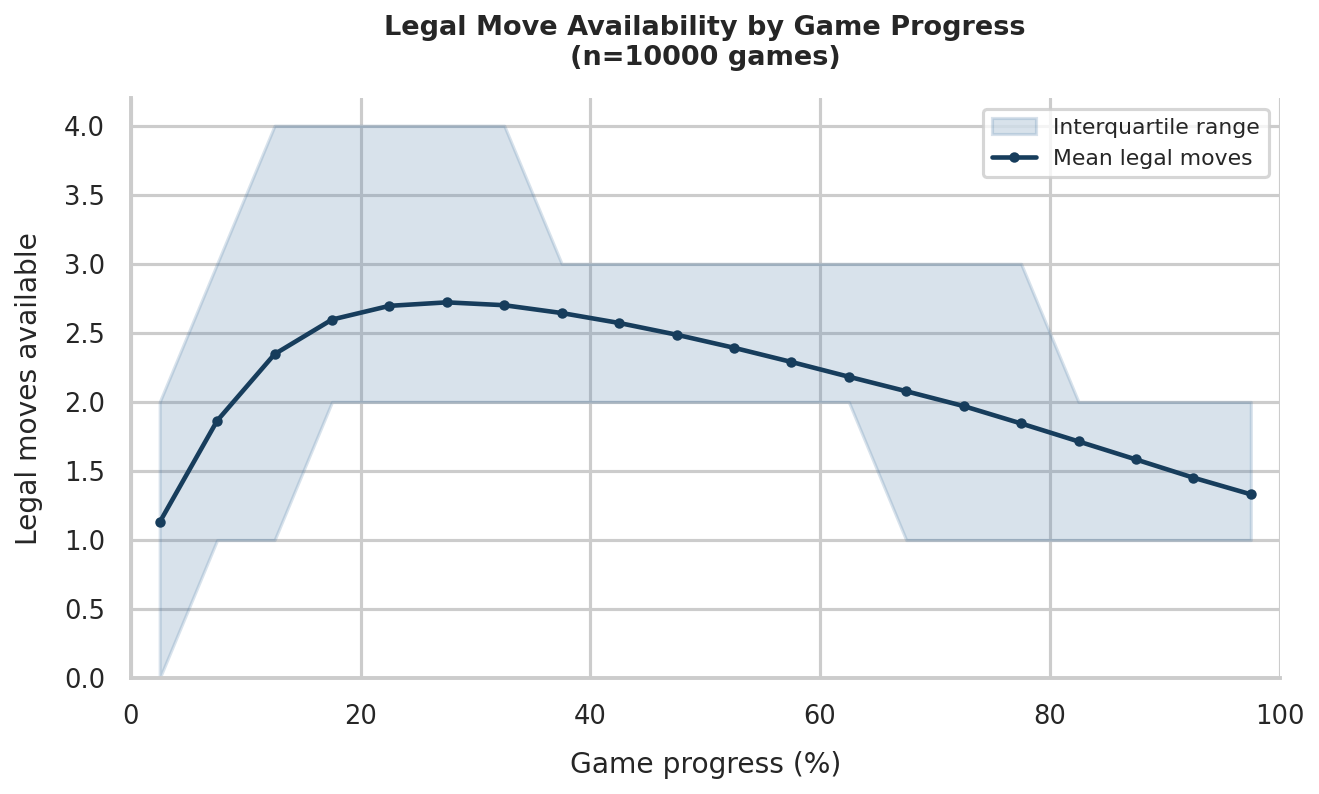

(<Figure size 1350x825 with 1 Axes>,
 <Axes: title={'center': 'Legal Move Availability by Game Progress\n(n=10000 games)'}, xlabel='Game progress (%)', ylabel='Legal moves available'>)

In [ ]:
plot_legal_moves_normalized(legal_move_count)

Mean Legal Moves: 2.1274196558716487
Median Legal Moves: 2.0


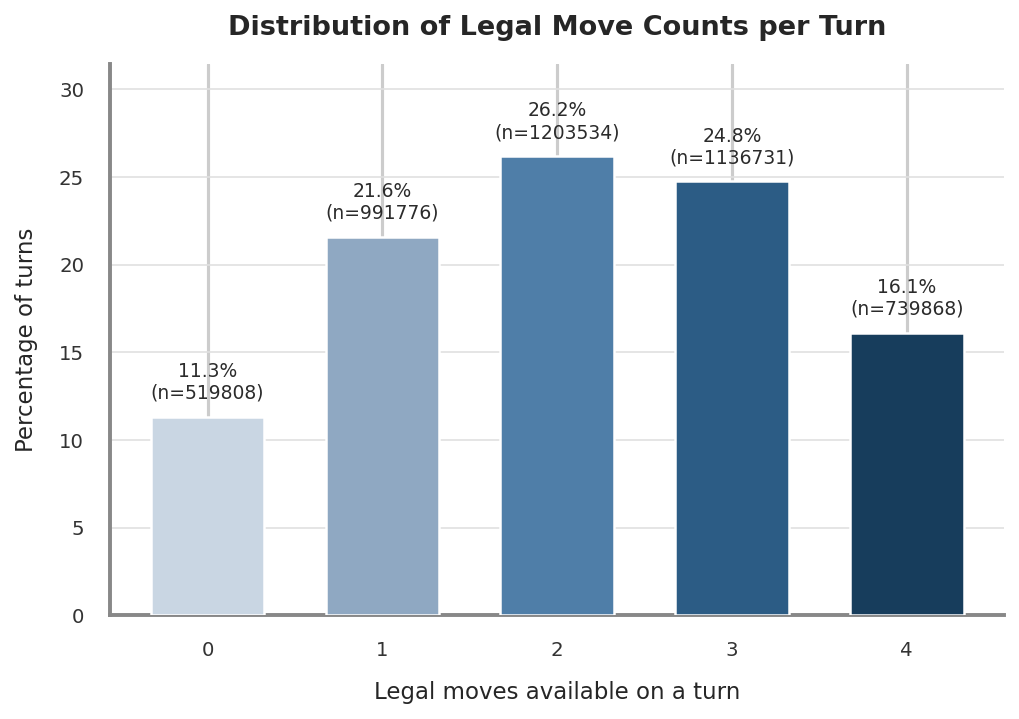

In [ ]:
flat_legal_move_count = [item for sublist in legal_move_count for item in sublist]

print(f"Mean Legal Moves: {np.mean(flat_legal_move_count)}")
print(f"Median Legal Moves: {np.median(flat_legal_move_count)}")

import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

counts = Counter(flat_legal_move_count)
values = list(range(0, 5))  # 0 to 4
frequencies = [counts.get(v, 0) for v in values]
total = sum(frequencies)
percentages = [f / total * 100 for f in frequencies]

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

colors = ["#c9d6e3", "#8fa8c2", "#4f7ea8", "#2c5c85", "#173d5c"]
bars = ax.bar(values, percentages, color=colors, edgecolor="white",
                linewidth=1.2, width=0.65, zorder=3)

for bar, pct, freq in zip(bars, percentages, frequencies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
              f"{pct:.1f}%\n(n={freq})", ha="center", va="bottom",
              fontsize=9, color="#2b2b2b")

ax.set_xlabel("Legal moves available on a turn", fontsize=11, labelpad=10)
ax.set_ylabel("Percentage of turns", fontsize=11, labelpad=10)
ax.set_title("Distribution of Legal Move Counts per Turn",
              fontsize=13, fontweight="bold", pad=14)

ax.set_xticks(values)
ax.set_ylim(0, max(percentages) * 1.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#888888")
ax.spines["bottom"].set_color("#888888")
ax.yaxis.grid(True, color="#e0e0e0", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(axis="both", labelsize=9.5, colors="#333333")

plt.tight_layout()
plt.show()

In [ ]:
trial = Trial(strategy_factories=[HeuristicStrategy, FastStrategy])
trial.play_num_times(1000)
trial.output_stats()

100%|██████████| 1000/1000 [00:10<00:00, 95.49it/s]


Trials Completed (1000 games, 2 players)

Results over 1000 games (2 players)

player1 (HeuristicStrategy)
  Wins: 836/1000
  Win rate: 83.6% ± 2.4%  (95% CI)
  Avg roll count on win: 85.85 ± 0.78  (95% CI)
  Avg distance from win when losing: 29.57 ± 5.05  (95% CI)
  Avg captures made per game: 1.49 ± 0.07  (95% CI)
  Avg times captured per game: 0.60 ± 0.05  (95% CI)
  Avg capture differential per game: +0.89 ± 0.08  (95% CI)

player2 (FastStrategy)
  Wins: 164/1000
  Win rate: 16.4% ± 2.4%  (95% CI)
  Avg roll count on win: 93.54 ± 1.90  (95% CI)
  Avg distance from win when losing: 77.55 ± 3.41  (95% CI)
  Avg captures made per game: 0.60 ± 0.05  (95% CI)
  Avg times captured per game: 1.49 ± 0.07  (95% CI)
  Avg capture differential per game: -0.89 ± 0.08  (95% CI)




# Ludo Animation (Made by Claude Fable 5)

In [ ]:
game = Game([Player("Expectimax 3-Ply", 0, ExpectimaxPlayer(heuristic = state_evaluator_two, depth=3)), Player("Heuristic", 26, HeuristicStrategy())], Board(), Dice())
game.start_game()

In [ ]:
import json
import re
from pathlib import Path

TRACK_LEN = 52
HOME_START = 52
FINISH = 58
SEAT_STARTS = [0, 13, 26, 39]

_RE = {
    "turn":      re.compile(r"^(.+?)'s turn\.$"),
    "roll":      re.compile(r"^(.+?) rolled a (\d+)$"),
    "moved":     re.compile(r"^(.+?) moved piece (\d+) (\d+) steps?$"),
    "activated": re.compile(r"^(.+?) activated piece (\d+)$"),
    "nomove":    re.compile(r"^(.+?) didn't move$"),
    "captured":  re.compile(r"^Piece (\d+) was captured!$"),
    "poshead":   re.compile(r"^(.+?)'s positions:$"),
    "piecepos":  re.compile(r"^Piece (\d+) is at position (-?\d+)$"),
    "winner":    re.compile(r"^Winner is (.+?)!$"),
}


def parse_log(log):
    """Parse a game log into (players, frames, winner)."""
    lines = log.split("\n") if isinstance(log, str) else list(log)
    lines = [ln.strip() for ln in lines if ln and ln.strip()]

    player_idx, players, pos = {}, [], []

    def ensure_player(name):
        if name not in player_idx:
            player_idx[name] = len(players)
            players.append({"name": name, "start": None})
            pos.append([-1, -1, -1, -1])
        return player_idx[name]

    frames = [{"pos": [], "player": None, "roll": None,
               "action": "Game started", "captured": []}]
    winner = None
    cur, cur_roll, cur_action = None, None, "waited"
    moved_piece, pending_caps, reading_pos_for = None, [], None

    def commit_turn():
        nonlocal cur, cur_roll, cur_action, moved_piece, pending_caps
        if cur is None:
            return
        caps = []
        dest = pos[cur][moved_piece] if moved_piece is not None else None
        for cid in pending_caps:
            owner = None
            for pi in range(len(players)):
                if pi != cur and dest is not None and pos[pi][cid] == dest:
                    owner = pi
                    break
            if owner is None and len(players) == 2:
                owner = 1 - cur
            if owner is not None:
                pos[owner][cid] = -1
                caps.append([owner, cid])
        frames.append({"pos": [list(p) for p in pos], "player": cur,
                       "roll": cur_roll, "action": cur_action, "captured": caps})
        cur, cur_roll, cur_action = None, None, "waited"
        moved_piece, pending_caps = None, []

    for ln in lines:
        m = _RE["turn"].match(ln)
        if m:
            commit_turn()
            cur = ensure_player(m.group(1))
            reading_pos_for = None
            continue
        m = _RE["roll"].match(ln)
        if m:
            cur_roll = int(m.group(2))
            continue
        m = _RE["moved"].match(ln)
        if m:
            moved_piece = int(m.group(2))
            cur_action = f"moved piece {moved_piece} {m.group(3)} steps"
            continue
        m = _RE["activated"].match(ln)
        if m:
            moved_piece = int(m.group(2))
            cur_action = f"activated piece {moved_piece}"
            continue
        if _RE["nomove"].match(ln):
            cur_action = "couldn't move"
            continue
        m = _RE["captured"].match(ln)
        if m:
            pending_caps.append(int(m.group(1)))
            continue
        m = _RE["poshead"].match(ln)
        if m:
            reading_pos_for = ensure_player(m.group(1))
            continue
        m = _RE["piecepos"].match(ln)
        if m and reading_pos_for is not None:
            pid, p = int(m.group(1)), int(m.group(2))
            old = pos[reading_pos_for][pid]
            pos[reading_pos_for][pid] = p
            pl = players[reading_pos_for]
            if pl["start"] is None and old == -1 and 0 <= p < TRACK_LEN:
                pl["start"] = p
            continue
        m = _RE["winner"].match(ln)
        if m:
            commit_turn()
            winner = m.group(1)
            continue

    commit_turn()

    for i, pl in enumerate(players):
        if pl["start"] is None:
            pl["start"] = SEAT_STARTS[i % 4]
    _assign_seats(players)

    frames[0]["pos"] = [[-1] * 4 for _ in players]
    return players, frames, winner


def _assign_seats(players):
    """Map each player to one of the four fixed seats by their start
    square (0->seat0, 13->seat1, 26->seat2, 39->seat3), nearest match,
    collisions pushed to the next free seat."""
    taken = set()
    for p in players:
        s = round(p["start"] / (TRACK_LEN / 4)) % 4
        while s in taken:
            s = (s + 1) % 4
        p["seat"] = s
        taken.add(s)


def animate_game(log, out="ludo_replay.html", title="Ludo replay",
                 safe_squares=None):
    """Parse `log` and write a self-contained animated HTML replay.

    safe_squares: iterable of ring indices to mark as safe. Defaults to
    the four seat start squares. Pass your engine's board.safeSquares
    for the real set."""
    players, frames, winner = parse_log(log)
    safe = sorted({int(s) for s in (safe_squares or SEAT_STARTS)
                   if 0 <= int(s) < TRACK_LEN})
    data = {
        "meta": {"trackLen": TRACK_LEN, "homeStart": HOME_START,
                 "finish": FINISH, "winner": winner, "title": title,
                 "seatStarts": SEAT_STARTS, "safeSquares": safe},
        "players": players,
        "frames": frames,
    }
    html = _TEMPLATE.replace("__DATA__", json.dumps(data))
    Path(out).write_text(html, encoding="utf-8")
    print(f"wrote {out}: {len(frames)} frames, {len(players)} players "
          f"(seats {[p['seat'] for p in players]}), winner: {winner}")
    return out


def show_in_notebook(path_or_html, height=780):
    """Colab-safe inline display: injects the HTML via a srcdoc iframe
    instead of pointing at a local file the frontend can't reach."""
    from IPython.display import HTML
    import html as _html
    p = Path(path_or_html)
    src = p.read_text(encoding="utf-8") if p.suffix == ".html" and p.exists() \
        else str(path_or_html)
    return HTML(f'<iframe srcdoc="{_html.escape(src, quote=True)}" '
                f'width="100%" height="{height}" style="border:0" '
                f'sandbox="allow-scripts"></iframe>')


_TEMPLATE = r"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>Ludo replay</title>
<link rel="preconnect" href="https://fonts.googleapis.com">
<link href="https://fonts.googleapis.com/css2?family=Space+Grotesk:wght@400;600&family=IBM+Plex+Mono:wght@400;600&display=swap" rel="stylesheet">
<style>
  :root{
    --felt:#12211c; --felt2:#0d1815; --cell:#243530; --cellline:#31463f;
    --bone:#e7e2d3; --dim:#9aa89f;
    --s0:#e2554f; --s1:#e0a53c; --s2:#579bd6; --s3:#6fbf73;
  }
  *{box-sizing:border-box; margin:0}
  body{
    background:radial-gradient(1200px 800px at 50% 30%, var(--felt), var(--felt2));
    color:var(--bone); font-family:'Space Grotesk',system-ui,sans-serif;
    min-height:100vh; display:flex; align-items:center; justify-content:center; padding:18px;
  }
  .wrap{display:flex; gap:26px; align-items:center; flex-wrap:wrap; justify-content:center; max-width:1120px}
  svg{max-width:min(92vw,660px); height:auto; display:block}
  .panel{width:300px; display:flex; flex-direction:column; gap:14px}
  h1{font-size:15px; font-weight:600; letter-spacing:.14em; text-transform:uppercase; color:var(--dim)}
  .die{font-size:88px; line-height:1; height:92px}
  .who{font-family:'IBM Plex Mono',monospace; font-size:14px}
  .who b{font-weight:600}
  .act{font-family:'IBM Plex Mono',monospace; font-size:13px; color:var(--dim); min-height:34px}
  .turnct{font-family:'IBM Plex Mono',monospace; font-size:12px; color:var(--dim); letter-spacing:.08em}
  input[type=range]{width:100%; accent-color:var(--bone)}
  .btns{display:flex; gap:8px}
  button,select{
    font-family:'Space Grotesk',sans-serif; font-size:14px; color:var(--bone);
    background:transparent; border:1px solid var(--cellline); border-radius:8px;
    padding:7px 12px; cursor:pointer;
  }
  button:hover{border-color:var(--bone)}
  button:focus-visible,select:focus-visible,input:focus-visible{outline:2px solid var(--bone); outline-offset:2px}
  button.play{min-width:74px}
  .winner{font-family:'IBM Plex Mono',monospace; font-size:13px; padding:8px 10px;
          border:1px dashed var(--cellline); border-radius:8px; display:none}
  .legend{display:flex; flex-direction:column; gap:5px; font-family:'IBM Plex Mono',monospace; font-size:12px; color:var(--dim)}
  .legend span{display:inline-flex; align-items:center; gap:8px}
  .dot{width:10px; height:10px; border-radius:50%; display:inline-block}
  @media (prefers-reduced-motion: reduce){ .noanim{transition:none !important} }
</style>
</head>
<body>
<div class="wrap">
  <svg id="board" viewBox="0 0 720 720" role="img" aria-label="Ludo board replay"></svg>
  <div class="panel">
    <h1 id="title">Ludo replay</h1>
    <div class="die" id="die">&#9856;</div>
    <div class="who" id="who">&nbsp;</div>
    <div class="act" id="act">&nbsp;</div>
    <div class="turnct" id="turnct"></div>
    <input type="range" id="scrub" min="0" value="0" step="1" aria-label="Turn">
    <div class="btns">
      <button id="restart" title="Restart">&#9198;</button>
      <button id="back" title="Step back">&#9664;</button>
      <button id="play" class="play">Play</button>
      <button id="fwd" title="Step forward">&#9654;</button>
      <select id="speed" aria-label="Speed">
        <option value="0.5">0.5&times;</option>
        <option value="1" selected>1&times;</option>
        <option value="2">2&times;</option>
        <option value="4">4&times;</option>
      </select>
    </div>
    <div class="winner" id="winner"></div>
    <div class="legend" id="legend"></div>
  </div>
</div>
<script>
const DATA = __DATA__;
const M = DATA.meta, P = DATA.players, F = DATA.frames;
const TAU = Math.PI*2;
const CX=360, CY=360, RING=252, CELL=13, PIECE=10;
const SEATCOL=['var(--s0)','var(--s1)','var(--s2)','var(--s3)'];
const DICE=['\u2680','\u2681','\u2682','\u2683','\u2684','\u2685'];
const reduced = matchMedia('(prefers-reduced-motion: reduce)').matches;
const occupied = [0,1,2,3].map(s => P.some(p => p.seat === s));

const ang = i => (i / M.trackLen) * TAU - Math.PI/2;
const ringXY = i => [CX + RING*Math.cos(ang(i)), CY + RING*Math.sin(ang(i))];

function homeXY(seat, q){                      // q in 52..57, spoke inward
  const a = ang((M.seatStarts[seat] - 2 + M.trackLen) % M.trackLen);
  const r = 206 - (q - M.homeStart) * 25;
  return [CX + r*Math.cos(a), CY + r*Math.sin(a)];
}
function yardXY(seat, pieceId){
  const a = ang(M.seatStarts[seat]), r = 312;
  const bx = CX + r*Math.cos(a), by = CY + r*Math.sin(a);
  return [bx + (pieceId%2)*26 - 13, by + Math.floor(pieceId/2)*26 - 13];
}
function finishXY(seat, pieceId){
  const a = ang(M.seatStarts[seat]);
  const bx = CX + 42*Math.cos(a), by = CY + 42*Math.sin(a);
  return [bx + (pieceId%2)*20 - 10, by + Math.floor(pieceId/2)*20 - 10];
}
function pieceXY(pIdx, pieceId, p){
  const seat = P[pIdx].seat;
  if (p === -1) return yardXY(seat, pieceId);
  if (p >= M.finish) return finishXY(seat, pieceId);
  if (p >= M.homeStart) return homeXY(seat, p);
  return ringXY(p);
}

// ---- static board ----------------------------------------------------------
const svg = document.getElementById('board');
const NS = 'http://www.w3.org/2000/svg';
function el(tag, attrs, parent){
  const e = document.createElementNS(NS, tag);
  for (const k in attrs) e.setAttribute(k, attrs[k]);
  (parent || svg).appendChild(e); return e;
}
el('circle', {cx:CX, cy:CY, r:RING+30, fill:'none', stroke:'var(--cellline)',
              'stroke-width':1, 'stroke-dasharray':'2 6'});
const seatOf = i => M.seatStarts.indexOf(i);
for (let i=0;i<M.trackLen;i++){
  const [x,y]=ringXY(i);
  const s = seatOf(i);
  el('circle',{cx:x,cy:y,r:CELL,fill:'var(--cell)',
               stroke:s>=0?SEATCOL[s]:'var(--cellline)',
               'stroke-width':s>=0?2.5:1});
  if (M.safeSquares.includes(i)){
    const star=el('text',{x:x,y:y,'text-anchor':'middle','dominant-baseline':'central',
      'font-size':11,fill:s>=0?SEATCOL[s]:'var(--bone)','fill-opacity':.75});
    star.textContent='\u2726';
  }
}
for (let s=0;s<4;s++){
  const ghost = occupied[s] ? 1 : 0.18;
  for(let q=M.homeStart;q<M.finish;q++){
    const [x,y]=homeXY(s,q);
    el('circle',{cx:x,cy:y,r:CELL-2,fill:'var(--cell)',stroke:SEATCOL[s],
                 'stroke-width':1,'stroke-opacity':.55*ghost+.001,
                 'fill-opacity':ghost});
  }
  for(let k=0;k<4;k++){
    const [x,y]=yardXY(s,k);
    el('circle',{cx:x,cy:y,r:CELL-1,fill:'none',stroke:SEATCOL[s],
                 'stroke-width':1,'stroke-opacity':.4*ghost+.001,
                 'stroke-dasharray':'3 4'});
  }
}
el('circle',{cx:CX,cy:CY,r:64,fill:'none',stroke:'var(--cellline)','stroke-width':1});

// ---- pieces ----------------------------------------------------------------
const pieces=[], cur=[];
P.forEach((p,pi)=>{ pieces[pi]=[]; cur[pi]=[];
  for(let k=0;k<4;k++){
    const [x,y]=yardXY(p.seat,k);
    const g=el('g',{});
    const c=el('circle',{cx:x,cy:y,r:PIECE,fill:SEATCOL[p.seat],
                         stroke:'var(--felt2)','stroke-width':2},g);
    const t=el('text',{x:x,y:y,'text-anchor':'middle','dominant-baseline':'central',
      'font-size':10,'font-family':"'IBM Plex Mono',monospace",fill:'var(--felt2)'},g);
    t.textContent=k;
    pieces[pi][k]={c,t}; cur[pi][k]=[x,y];
  }
});

function stackOffsets(frame){
  const seen={};
  const out=P.map(()=>[[0,0],[0,0],[0,0],[0,0]]);
  P.forEach((p,pi)=>frame.pos[pi].forEach((pos,k)=>{
    if(pos>=0 && pos<M.homeStart){
      (seen[pos]=seen[pos]||[]).push([pi,k]);
    }
  }));
  for(const key in seen){
    const grp=seen[key];
    if(grp.length>1) grp.forEach(([pi,k],j)=>{
      out[pi][k]=[(j%2)*10-5, Math.floor(j/2)*10-5];
    });
  }
  return out;
}

let raf=null;
function renderFrame(fi, animate){
  const f=F[fi], offs=stackOffsets(f);
  const targets=[];
  P.forEach((p,pi)=>f.pos[pi].forEach((pos,k)=>{
    const [tx,ty]=pieceXY(pi,k,pos);
    targets.push([pi,k,tx+offs[pi][k][0],ty+offs[pi][k][1]]);
  }));
  if(raf) cancelAnimationFrame(raf);
  if(!animate || reduced){
    targets.forEach(([pi,k,tx,ty])=>{setXY(pi,k,tx,ty); cur[pi][k]=[tx,ty];});
  } else {
    const from=targets.map(([pi,k])=>[...cur[pi][k]]);
    const t0=performance.now(), DUR=300;
    const step=now=>{
      const u=Math.min(1,(now-t0)/DUR), e=1-Math.pow(1-u,3);
      targets.forEach(([pi,k,tx,ty],j)=>{
        const x=from[j][0]+(tx-from[j][0])*e, y=from[j][1]+(ty-from[j][1])*e;
        setXY(pi,k,x,y); cur[pi][k]=[x,y];
      });
      if(u<1) raf=requestAnimationFrame(step);
    };
    raf=requestAnimationFrame(step);
  }
  die.innerHTML = f.roll ? DICE[f.roll-1] : '&#8212;';
  die.style.color = f.player!=null ? cssColor(P[f.player].seat) : 'var(--dim)';
  who.innerHTML = f.player!=null
    ? `<b style="color:${cssColor(P[f.player].seat)}">${P[f.player].name}</b> rolled ${f.roll??'&#8212;'}`
    : '&nbsp;';
  act.textContent = f.action + (f.captured.length
    ? `  \u2014 captured ${f.captured.map(c=>P[c[0]].name+' piece '+c[1]).join(', ')}!` : '');
  turnct.textContent = `TURN ${String(fi).padStart(3,'0')} / ${F.length-1}`;
  scrub.value=fi;
  winnerBox.style.display = (fi===F.length-1 && M.winner) ? 'block' : 'none';
  winnerBox.textContent = M.winner ? `Winner: ${M.winner}` : '';
}
function setXY(pi,k,x,y){
  pieces[pi][k].c.setAttribute('cx',x); pieces[pi][k].c.setAttribute('cy',y);
  pieces[pi][k].t.setAttribute('x',x);  pieces[pi][k].t.setAttribute('y',y);
}
function cssColor(seat){
  return getComputedStyle(document.documentElement)
    .getPropertyValue(['--s0','--s1','--s2','--s3'][seat]).trim();
}

// ---- controls --------------------------------------------------------------
const die=document.getElementById('die'), who=document.getElementById('who'),
  act=document.getElementById('act'), turnct=document.getElementById('turnct'),
  scrub=document.getElementById('scrub'), winnerBox=document.getElementById('winner'),
  playBtn=document.getElementById('play'), speedSel=document.getElementById('speed');
document.getElementById('title').textContent = M.title;
scrub.max = F.length-1;

const legend=document.getElementById('legend');
P.forEach((p,pi)=>{
  const s=document.createElement('span');
  s.innerHTML=`<i class="dot" style="background:${cssColor(p.seat)}"></i>${p.name}`
    + (M.winner===p.name ? ' \u2605' : '');
  legend.appendChild(s);
});

let fi=0, timer=null;
function goto(i, animate=true){ fi=Math.max(0,Math.min(F.length-1,i)); renderFrame(fi,animate); }
function stop(){ if(timer){clearInterval(timer); timer=null;} playBtn.textContent='Play'; }
function play(){
  if(timer) return stop();
  if(fi>=F.length-1) goto(0,false);
  playBtn.textContent='Pause';
  timer=setInterval(()=>{
    if(fi>=F.length-1) return stop();
    goto(fi+1);
  }, 650/parseFloat(speedSel.value));
}
playBtn.onclick=play;
speedSel.onchange=()=>{ if(timer){stop(); play();} };
document.getElementById('fwd').onclick=()=>{stop(); goto(fi+1);};
document.getElementById('back').onclick=()=>{stop(); goto(fi-1);};
document.getElementById('restart').onclick=()=>{stop(); goto(0,false);};
scrub.oninput=e=>{stop(); goto(parseInt(e.target.value),false);};
addEventListener('keydown',e=>{
  if(e.key===' '){e.preventDefault(); play();}
  if(e.key==='ArrowRight'){stop(); goto(fi+1);}
  if(e.key==='ArrowLeft'){stop(); goto(fi-1);}
});
goto(0,false);
</script>
</body>
</html>
"""


if __name__ == "__main__":
    def block(name, roll, action, positions_by_player):
        lines = [f"{name}'s turn.", f"{name} rolled a {roll}"]
        if action:
            lines.append(f"{name} {action}")
        else:
            lines.append(f"{name} didn't move")
        for pname, ps in positions_by_player:
            lines.append(f"{pname}'s positions:")
            for i, p in enumerate(ps):
                lines.append(f"Piece {i} is at position {p}")
        return lines


In [ ]:
animate_game(game.log, out="ludo_replay.html", title="")
show_in_notebook("ludo_replay.html")

wrote ludo_replay.html: 231 frames, 2 players (seats [2, 0]), winner: Expectimax 3-Ply


/usr/local/lib/python3.13/dist-packages/IPython/core/display.py:724: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")
